# 🎙️ Binary Acoustic Classification at the Edge
## MFCC + Linear Perceptron  vs.  Random Forest  vs.  1D-CNN
### Production-Ready Research Pipeline — IEEE IoT-J Submission

**Paper:** *"Extreme Minimalism for Always-On Acoustic Triggering: MFCC-Driven Linear Perceptron Deployment on Sub-mW IoT Microcontrollers"*

| Property | Value |
|---|---|
| Dataset | ESC-50 Environmental Sound Classification (2 000 clips, 50 classes) |
| Binary task | Vacuum Cleaner (positive) vs. all other sounds (negative) |
| Evaluation | 5-fold cross-validation + transfer learning + MFCC ablation |
| Runtime | CPU sufficient — GPU used automatically by TensorFlow if available |

> **Instructions:** Run all cells top-to-bottom. Do not skip cells. Each cell is one self-contained pipeline stage.

---
## Table of Contents
| # | Section |
|---|---|
| 1–2 | Setup: dependencies, imports, config |
| 3–5 | Data: download, preprocessing, MFCC features |
| 6 | Architecture: CNN + focal loss definition |
| 7–10 | **5-Fold Cross-Validation** (main results) |
| 11–19 | **Single-Fold Analysis** (fold 5): evaluation, plots, C export |
| 20–22 | **Transfer Learning**: chainsaw + hand_saw |
| 23–26 | **Ablation Study**: MFCC feature configurations |
| 27 | Final summary dashboard |


---
## Part 1 — Setup
### Cell 1 — Install Dependencies

In [30]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — Install & Upgrade Dependencies (Conditional)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import importlib.util
import sys

def check_and_install(package_name, install_name=None):
    if install_name is None:
        install_name = package_name
    if importlib.util.find_spec(package_name) is None:
        print(f"⌒ {install_name} not found. Installing...")
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", install_name])
    else:
        print(f"✅ {package_name} is already installed.")

# List of required packages
packages = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("librosa", None),
    ("soundfile", None),
    ("audioread", None),
    ("sklearn", "scikit-learn"),
    ("imblearn", "imbalanced-learn"),
    ("tensorflow", None),
    ("matplotlib", None),
    ("seaborn", None),
    ("tqdm", None),
    ("tabulate", None)
]

for pkg, inst in packages:
    check_and_install(pkg, inst)

print("\n✅  Dependency check complete.")

✅ numpy is already installed.
✅ pandas is already installed.
✅ librosa is already installed.
✅ soundfile is already installed.
✅ audioread is already installed.
✅ sklearn is already installed.
✅ imblearn is already installed.
✅ tensorflow is already installed.
✅ matplotlib is already installed.
✅ seaborn is already installed.
✅ tqdm is already installed.
✅ tabulate is already installed.

✅  Dependency check complete.


### Cell 2 — Imports & Global Configuration

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Imports & Global Configuration
# ─────────────────────────────────────────────────────────────────────────────
import os, time, json, struct, warnings, logging, sys
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, average_precision_score,
    precision_recall_curve, matthews_corrcoef,
)
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

warnings.filterwarnings("ignore")

# ── Logging Configuration (Output to console) ────────────────────────────────
log = logging.getLogger("acoustic_edge")
log.setLevel(logging.INFO)
if not log.handlers:
    handler = logging.StreamHandler(sys.stdout)
    handler.setFormatter(logging.Formatter("%(levelname)s | %(message)s"))
    log.addHandler(handler)

# ── Global Dataset Toggle ────────────────────────────────────────────
DATASET = "ESC50"   # switch to "US8K" for UrbanSound8K evaluation

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Global Config (single source of truth) ─────────────────────────────
@dataclass
class Config:
    dataset_mode   : str   = DATASET

    # Paths
    data_dir       : Path = Path("./esc50") if DATASET == "ESC50" else Path("./us8k")
    output_dir     : Path = Path("./results")
    model_dir      : Path = Path("./models")

    # Audio
    sample_rate    : int   = 16_000
    clip_duration  : float = 5.0
    target_samples : int   = 0               # computed in __post_init__

    # MFCC
    n_mfcc         : int   = 13
    n_fft          : int   = 512             # 32 ms window @ 16 kHz
    hop_length     : int   = 160             # 10 ms hop
    n_mels         : int   = 26
    fmin           : float = 0.0
    fmax           : float = 8_000.0
    delta_order    : int   = 2               # Δ and ΔΔ → 39-dim vector

    # Feature vector
    feature_dim    : int   = 0               # computed: n_mfcc * (1 + delta_order)

    # CNN sequence length
    max_frames     : int   = 500

    # Dataset specific target
    target_class   : str   = "vacuum_cleaner" if DATASET == "ESC50" else "drilling"
    test_size      : float = 0.10
    val_size       : float = 0.10

    # Training hyperparameters
    rf_n_estimators: int   = 200
    rf_max_depth   : int   = 10
    perc_max_iter  : int   = 1_000
    perc_tol       : float = 1e-4
    cnn_epochs     : int   = 60
    cnn_batch_size : int   = 32
    cnn_lr         : float = 1e-3

    # MCU power constants — Cortex-M0+ @ 3.3 V, 48 MHz (datasheet)
    mcu_active_ma  : float = 4.6
    mcu_voltage    : float = 3.3

    def __post_init__(self):
        self.target_samples = int(self.sample_rate * self.clip_duration)
        self.feature_dim    = self.n_mfcc * (1 + self.delta_order)
        for p in [self.output_dir, self.model_dir]:
            p.mkdir(parents=True, exist_ok=True)

CFG = Config()
log.info(f"Dataset Mode       : {CFG.dataset_mode}")
log.info(f"Target Class       : {CFG.target_class}")
log.info(f"Feature vector dim : {CFG.feature_dim}")
print("✅  Config initialised with dataset toggle.")

INFO | Dataset Mode       : ESC50


INFO:acoustic_edge:Dataset Mode       : ESC50


INFO | Target Class       : vacuum_cleaner


INFO:acoustic_edge:Target Class       : vacuum_cleaner


INFO | Feature vector dim : 39


INFO:acoustic_edge:Feature vector dim : 39


✅  Config initialised with dataset toggle.


---
## Part 2 — Data
### Cell 3 — Download & Verify ESC-50

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Download & Verify ESC-50 Dataset
# ─────────────────────────────────────────────────────────────────────────────
import urllib.request, zipfile

ESC50_URL = "https://github.com/karoldvl/ESC-50/archive/master.zip"
ZIP_PATH  = Path("./esc50.zip")

def download_with_progress(url: str, dest: Path) -> None:
    if dest.exists():
        log.info(f"Archive {dest} already present — skipping download.")
        return
    log.info(f"Downloading from {url} …")
    with urllib.request.urlopen(url) as resp:
        total = int(resp.headers.get("Content-Length", 0))
        chunk = 1 << 16
        downloaded = 0
        with open(dest, "wb") as f, tqdm(
            total=total, unit="B", unit_scale=True, desc=dest.name
        ) as pbar:
            while True:
                buf = resp.read(chunk)
                if not buf:
                    break
                f.write(buf)
                downloaded += len(buf)
                pbar.update(len(buf))
    log.info(f"Saved → {dest}  ({downloaded / 1e6:.1f} MB)")

def extract_esc50(zip_path: Path, dest: Path) -> Path:
    if dest.exists() and any(dest.rglob("*.wav")):
        log.info("ESC-50 already extracted.")
    else:
        log.info("Extracting ESC-50 …")
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(".")
        src = Path("./ESC-50-master")
        src.rename(dest)
    return dest

# Execution
download_with_progress(ESC50_URL, ZIP_PATH)
dataset_root = extract_esc50(ZIP_PATH, CFG.data_dir)

# Load metadata
meta = pd.read_csv(dataset_root / "meta" / "esc50.csv")
meta["filepath"] = meta["filename"].apply(lambda fn: str(dataset_root / "audio" / fn))
meta["label"] = (meta["category"] == CFG.target_class).astype(int)

log.info(f"Total clips    : {len(meta)}")
log.info(f"Target class   : '{CFG.target_class}'")
print("✅  ESC-50 dataset downloaded and verified.")

INFO | Archive esc50.zip already present — skipping download.


INFO:acoustic_edge:Archive esc50.zip already present — skipping download.


INFO | ESC-50 already extracted.


INFO:acoustic_edge:ESC-50 already extracted.


INFO | Total clips    : 2000


INFO:acoustic_edge:Total clips    : 2000


INFO | Target class   : 'vacuum_cleaner'


INFO:acoustic_edge:Target class   : 'vacuum_cleaner'


✅  ESC-50 dataset downloaded and verified.


### Cell 4 — Audio Preprocessing

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Audio Preprocessing (with Caching)
# ─────────────────────────────────────────────────────────────────────────────

CACHE_FILE = CFG.data_dir / "esc50_waveforms_cache.npz"

def load_and_preprocess(filepath: str, cfg: Config) -> np.ndarray:
    y, sr = librosa.load(filepath, sr=None, mono=True)
    if sr != cfg.sample_rate:
        y = librosa.resample(y, orig_sr=sr, target_sr=cfg.sample_rate)
    y, _ = librosa.effects.trim(y, top_db=20)
    if len(y) < cfg.target_samples:
        y = np.pad(y, (0, cfg.target_samples - len(y)), mode="constant")
    else:
        y = y[: cfg.target_samples]
    peak = np.max(np.abs(y))
    if peak > 0:
        y = y / peak
    return y.astype(np.float32)

waveforms: Dict[str, np.ndarray] = {}

if CACHE_FILE.exists():
    log.info(f"Loading waveforms from cache: {CACHE_FILE}")
    with np.load(CACHE_FILE) as data:
        waveforms = {name: data[name] for name in data.files}
    log.info(f"Successfully loaded {len(waveforms)} clips from cache.")
else:
    log.info("No cache found. Processing raw audio files...")
    errors: List[str] = []
    for _, row in tqdm(meta.iterrows(), total=len(meta), desc="Preprocessing"):
        try:
            waveforms[row['filename']] = load_and_preprocess(row['filepath'], CFG)
        except Exception as exc:
            errors.append(row['filename'])

    if errors:
        log.warning(f"{len(errors)} files failed to load.")
        meta = meta[~meta['filename'].isin(errors)].reset_index(drop=True)

    # Save to cache
    log.info(f"Saving processed waveforms to cache: {CACHE_FILE}")
    np.savez_compressed(CACHE_FILE, **waveforms)

if waveforms:
    log.info(f"Waveforms ready: {len(waveforms)}")
    print("✅  Audio preprocessing (with caching) complete.")
else:
    log.error("❌ No waveforms loaded.")

INFO | No cache found. Processing raw audio files...


INFO:acoustic_edge:No cache found. Processing raw audio files...


Preprocessing:   0%|          | 0/2000 [00:00<?, ?it/s]

INFO | Saving processed waveforms to cache: esc50/esc50_waveforms_cache.npz


INFO:acoustic_edge:Saving processed waveforms to cache: esc50/esc50_waveforms_cache.npz


INFO | Waveforms ready: 2000


INFO:acoustic_edge:Waveforms ready: 2000


✅  Audio preprocessing (with caching) complete.


### Cell 5 — MFCC Feature Extraction

Extracting MFCC Features:   0%|          | 0/2000 [00:00<?, ?it/s]

INFO | X_vec shape : (2000, 39)   (39-dim vector)


INFO:acoustic_edge:X_vec shape : (2000, 39)   (39-dim vector)


INFO | X_seq shape : (2000, 500, 39)  (39-dim sequence)


INFO:acoustic_edge:X_seq shape : (2000, 500, 39)  (39-dim sequence)


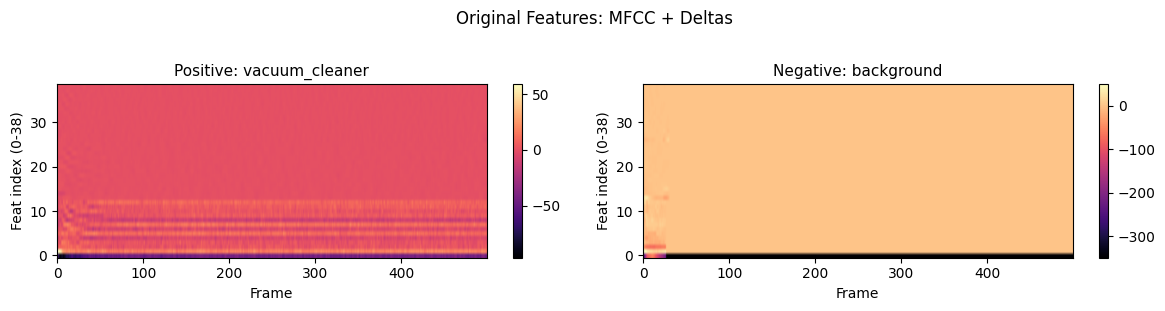

✅  Standard MFCC feature extraction complete (39-dim).


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — MFCC Feature Extraction (Original Clean Version)
# Per clip: 13 MFCC + 13 Δ + 13 ΔΔ = 39 dimensions
# ─────────────────────────────────────────────────────────────────────────────

def extract_mfcc_vector(y: np.ndarray, cfg: Config) -> np.ndarray:
    mfcc = librosa.feature.mfcc(
        y=y, sr=cfg.sample_rate, n_mfcc=cfg.n_mfcc,
        n_fft=cfg.n_fft, hop_length=cfg.hop_length,
        n_mels=cfg.n_mels, fmin=cfg.fmin, fmax=cfg.fmax,
    )
    features = [mfcc]
    for order in range(1, cfg.delta_order + 1):
        features.append(librosa.feature.delta(mfcc, order=order))
    return np.vstack(features).mean(axis=1).astype(np.float32)

def extract_mfcc_sequence(y: np.ndarray, cfg: Config) -> np.ndarray:
    mfcc = librosa.feature.mfcc(
        y=y, sr=cfg.sample_rate, n_mfcc=cfg.n_mfcc,
        n_fft=cfg.n_fft, hop_length=cfg.hop_length,
        n_mels=cfg.n_mels, fmin=cfg.fmin, fmax=cfg.fmax,
    )
    features = [mfcc]
    for order in range(1, cfg.delta_order + 1):
        features.append(librosa.feature.delta(mfcc, order=order))
    stacked = np.vstack(features).T
    T = stacked.shape[0]
    if T < cfg.max_frames:
        stacked = np.vstack([stacked,
            np.zeros((cfg.max_frames - T, cfg.feature_dim), dtype=np.float32)])
    else:
        stacked = stacked[: cfg.max_frames]
    return stacked.astype(np.float32)

# Reset Global Config to original 39-dim
CFG.feature_dim = 39

X_vec, X_seq, y_all = [], [], []
for _, row in tqdm(meta.iterrows(), total=len(meta), desc="Extracting MFCC Features"):
    wave = waveforms[row["filename"]]
    X_vec.append(extract_mfcc_vector(wave, CFG))
    X_seq.append(extract_mfcc_sequence(wave, CFG))
    y_all.append(row["label"])

X_vec = np.array(X_vec, dtype=np.float32)
X_seq = np.array(X_seq, dtype=np.float32)
y_all = np.array(y_all, dtype=np.int32)

log.info(f"X_vec shape : {X_vec.shape}   (39-dim vector)")
log.info(f"X_seq shape : {X_seq.shape}  (39-dim sequence)")

# Visualize
pos_idx = np.where(y_all == 1)[0][0]
neg_idx = np.where(y_all == 0)[0][0]
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, idx, title in zip(axes,
    [pos_idx, neg_idx],
    [f"Positive: {CFG.target_class}", "Negative: background"]):
    img = ax.imshow(X_seq[idx].T, aspect="auto", origin="lower", cmap="magma")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Frame"); ax.set_ylabel("Feat index (0-38)")
    plt.colorbar(img, ax=ax)
plt.suptitle("Original Features: MFCC + Deltas", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()
print("✅  Standard MFCC feature extraction complete (39-dim).")

---
## Part 3 — Model Architecture
### Cell 6 — CNN Architecture & Focal Loss Definition

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — CNN Architecture + Focal Loss
# Updated to use direct Model and Input imports to avoid naming conflicts.
# ─────────────────────────────────────────────────────────────────────────────

def focal_loss(gamma: float = 2.0, alpha: float = 0.75):
    """Focal loss — down-weights easy negatives, focuses on hard positives."""
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        bce    = tf.keras.backend.binary_crossentropy(y_true, y_pred)
        p_t    = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return alpha * tf.pow(1.0 - p_t, gamma) * bce
    return loss

def build_cnn(input_shape: tuple) -> Model:
    """
    1-D CNN for MFCC sequence classification.
    Input shape: (max_frames, feature_dim)
    """
    inp = Input(shape=input_shape)
    x = layers.Conv1D(32, 3, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Conv1D(64, 3, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = Model(inp, out, name='CNN_1D')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(CFG.cnn_lr),
        loss=focal_loss(gamma=2.0, alpha=0.75),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
    )
    return model

# Quick sanity check
_test = build_cnn((CFG.max_frames, CFG.feature_dim))
print(f'✅  CNN architecture ready  |  params: {_test.count_params():,}')
del _test

✅  CNN architecture ready  |  params: 14,593


---
## Part 4 — 5-Fold Cross-Validation
> This is the **primary result** reported in the paper.
> All 5 ESC-50 folds are used as test set in rotation.
> Val set = one remaining fold. Train set = the other three.
> SMOTE applied to training data only.

### Cell 7 — 5-Fold CV Driver

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — 5-Fold Cross-Validation Driver
# Trains and evaluates all 3 models on each fold.
# Val set = one of the remaining 4 folds (always fold before test).
# ─────────────────────────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample as sk_resample

FOLDS = [1, 2, 3, 4, 5]
all_fold_results = []   # one dict per (fold, model)

for test_fold in FOLDS:
    print(f"\n{'='*60}")
    print(f"  TEST FOLD : {test_fold}")
    print(f"{'='*60}")

    # Val fold = the fold just before test (wraps around)
    val_fold   = (test_fold - 2) % 5 + 1
    train_folds = [f for f in FOLDS if f not in [test_fold, val_fold]]

    train_mask = meta["fold"].isin(train_folds).values
    val_mask   = (meta["fold"] == val_fold).values
    test_mask  = (meta["fold"] == test_fold).values

    X_tr_vec, y_tr = X_vec[train_mask], y_all[train_mask]
    X_va_vec, y_va = X_vec[val_mask],   y_all[val_mask]
    X_te_vec, y_te = X_vec[test_mask],  y_all[test_mask]

    X_tr_seq = X_seq[train_mask]
    X_va_seq = X_seq[val_mask]
    X_te_seq = X_seq[test_mask]

    # ── Scaler: fit on train only ─────────────────────────────────────────────
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr_vec)
    X_va_sc = sc.transform(X_va_vec)
    X_te_sc = sc.transform(X_te_vec)

    # ── SMOTE on training set only ────────────────────────────────────────────
    k = min(5, y_tr.sum() - 1)
    smote = SMOTE(random_state=SEED, sampling_strategy=0.15, k_neighbors=k)
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_sc, y_tr)
    log.info(f"Fold {test_fold} | After SMOTE: pos={y_tr_sm.sum()} neg={(y_tr_sm==0).sum()}")

    # ── Class weight for CNN ──────────────────────────────────────────────────
    cw = {0: 1.0, 1: float((y_tr==0).sum() / max(y_tr.sum(), 1))}

    # ── Threshold search helper ───────────────────────────────────────────────
    def best_threshold(proba_val, y_val, max_t=0.65):
        best_t, best_f = 0.5, 0.0
        for t in np.arange(0.05, max_t, 0.01):
            f = f1_score(y_val, (proba_val >= t).astype(int), zero_division=0)
            if f > best_f:
                best_f, best_t = f, t
        return best_t

    # ──────────────────────────────────────────────────────────────────────────
    # MODEL A — Linear Perceptron
    # ──────────────────────────────────────────────────────────────────────────
    perc = CalibratedClassifierCV(
        SGDClassifier(loss="hinge", max_iter=1000, tol=1e-4,
                      random_state=SEED, class_weight="balanced",
                      early_stopping=True, validation_fraction=0.1,
                      n_iter_no_change=20),
        cv=5, method="sigmoid",
    )
    perc.fit(X_tr_sm, y_tr_sm)

    perc_val_prob = perc.predict_proba(X_va_sc)[:, 1]
    t_perc        = best_threshold(perc_val_prob, y_va)
    perc_prob     = perc.predict_proba(X_te_sc)[:, 1]
    perc_pred     = (perc_prob >= t_perc).astype(int)

    # ──────────────────────────────────────────────────────────────────────────
    # MODEL B — Random Forest
    # ──────────────────────────────────────────────────────────────────────────
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight="balanced",
        random_state=SEED, n_jobs=-1,
    )
    rf.fit(X_tr_sm, y_tr_sm)

    rf_val_prob = rf.predict_proba(X_va_sc)[:, 1]
    t_rf        = best_threshold(rf_val_prob, y_va)
    rf_prob     = rf.predict_proba(X_te_sc)[:, 1]
    rf_pred     = (rf_prob >= t_rf).astype(int)

    # ──────────────────────────────────────────────────────────────────────────
    # MODEL C — 1D CNN
    # ──────────────────────────────────────────────────────────────────────────
    cnn = build_cnn((CFG.max_frames, CFG.feature_dim))
    cnn.fit(
        X_tr_seq, y_tr,
        validation_data=(X_va_seq, y_va),
        epochs=CFG.cnn_epochs,
        batch_size=CFG.cnn_batch_size,
        class_weight=cw,
        callbacks=[
            callbacks.EarlyStopping(monitor="val_auc", patience=10,
                                    restore_best_weights=True, mode="max"),
            callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                        patience=5, min_lr=1e-6),
        ],
        verbose=0,
    )

    cnn_val_prob = cnn.predict(X_va_seq, verbose=0).ravel()
    t_cnn        = best_threshold(cnn_val_prob, y_va)
    cnn_prob     = cnn.predict(X_te_seq, verbose=0).ravel()
    cnn_pred     = (cnn_prob >= t_cnn).astype(int)

    # ──────────────────────────────────────────────────────────────────────────
    # Collect results for this fold
    # ──────────────────────────────────────────────────────────────────────────
    for name, pred, prob in [
        ("Linear Perceptron", perc_pred, perc_prob),
        ("Random Forest",     rf_pred,   rf_prob),
        ("1D-CNN",            cnn_pred,  cnn_prob),
    ]:
        tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
        all_fold_results.append({
            "fold"      : test_fold,
            "model"     : name,
            "accuracy"  : accuracy_score(y_te, pred),
            "f1"        : f1_score(y_te, pred, zero_division=0),
            "auc_roc"   : roc_auc_score(y_te, prob),
            "auc_pr"    : average_precision_score(y_te, prob),
            "precision" : tp / max(tp + fp, 1),
            "recall"    : tp / max(tp + fn, 1),
            "fpr"       : fp / max(fp + tn, 1),
            "mcc"       : matthews_corrcoef(y_te, pred),
            "threshold" : t_perc if name == "Linear Perceptron"
                          else (t_rf if name == "Random Forest" else t_cnn),
        })
        current_f1 = f1_score(y_te, pred, zero_division=0)
        print(f"  {name:<22} | F1={current_f1:.3f}  AUC={roc_auc_score(y_te,prob):.3f}  T={all_fold_results[-1]['threshold']:.2f}")

print("\n✅  All 5 folds complete.")


  TEST FOLD : 1
INFO | Fold 1 | After SMOTE: pos=176 neg=1176


INFO:acoustic_edge:Fold 1 | After SMOTE: pos=176 neg=1176


  Linear Perceptron      | F1=0.194  AUC=0.923  T=0.39
  Random Forest          | F1=0.143  AUC=0.928  T=0.33
  1D-CNN                 | F1=0.242  AUC=0.940  T=0.64

  TEST FOLD : 2
INFO | Fold 2 | After SMOTE: pos=176 neg=1176


INFO:acoustic_edge:Fold 2 | After SMOTE: pos=176 neg=1176


  Linear Perceptron      | F1=0.286  AUC=0.952  T=0.32
  Random Forest          | F1=0.667  AUC=0.923  T=0.24
  1D-CNN                 | F1=0.516  AUC=0.986  T=0.59

  TEST FOLD : 3
INFO | Fold 3 | After SMOTE: pos=176 neg=1176


...

  Linear Perceptron      | F1=0.133  AUC=0.837  T=0.61
  Random Forest          | F1=0.471  AUC=0.816  T=0.24
  1D-CNN                 | F1=0.400  AUC=0.953  T=0.61

  TEST FOLD : 4
INFO | Fold 4 | After SMOTE: pos=176 neg=1176


INFO:acoustic_edge:Fold 4 | After SMOTE: pos=176 neg=1176


  Linear Perceptron      | F1=0.235  AUC=0.891  T=0.35
  Random Forest          | F1=0.571  AUC=0.964  T=0.24
  1D-CNN                 | F1=0.364  AUC=0.970  T=0.62

  TEST FOLD : 5
INFO | Fold 5 | After SMOTE: pos=176 neg=1176


INFO:acoustic_edge:Fold 5 | After SMOTE: pos=176 neg=1176


  Linear Perceptron      | F1=0.258  AUC=0.887  T=0.53
  Random Forest          | F1=0.316  AUC=0.867  T=0.27
  1D-CNN                 | F1=0.316  AUC=0.916  T=0.63

✅  All 5 folds complete.


### Cell 8 — Aggregate 5-Fold Results

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Aggregate 5-Fold Results
# ─────────────────────────────────────────────────────────────────────────────

fold_df = pd.DataFrame(all_fold_results)

agg = fold_df.groupby('model').agg(
    f1_mean    =('f1',       'mean'),  f1_std    =('f1',       'std'),
    auc_mean   =('auc_roc',  'mean'),  auc_std   =('auc_roc',  'std'),
    auc_pr_mean=('auc_pr',   'mean'),  auc_pr_std=('auc_pr',   'std'),
    fpr_mean   =('fpr',      'mean'),  fpr_std   =('fpr',      'std'),
    acc_mean   =('accuracy', 'mean'),  acc_std   =('accuracy', 'std'),
    mcc_mean   =('mcc',      'mean'),  mcc_std   =('mcc',      'std'),
).round(4)

MODEL_ORDER = ['Linear Perceptron', 'Random Forest', '1D-CNN']
COLORS      = {'Linear Perceptron': '#E85D24', 'Random Forest': '#4A90D9', '1D-CNN': '#2DA86D'}

print('\n' + '═'*70)
print('  5-FOLD CROSS-VALIDATION SUMMARY  (mean ± std across folds)')
print('═'*70)
for model in MODEL_ORDER:
    r = agg.loc[model]
    print(f'\n  {model}')
    print(f'    F1       : {r.f1_mean:.3f} ± {r.f1_std:.3f}')
    print(f'    AUC-ROC  : {r.auc_mean:.3f} ± {r.auc_std:.3f}')
    print(f'    AUC-PR   : {r.auc_pr_mean:.3f} ± {r.auc_pr_std:.3f}')
    print(f'    FPR      : {r.fpr_mean:.3f} ± {r.fpr_std:.3f}')
    print(f'    Accuracy : {r.acc_mean:.3f} ± {r.acc_std:.3f}')
    print(f'    MCC      : {r.mcc_mean:.3f} ± {r.mcc_std:.3f}')
print('\n' + '═'*70)

fold_df.to_csv(CFG.output_dir / 'cv5_per_fold.csv', index=False)
agg.to_csv(CFG.output_dir / 'cv5_summary.csv')
print('✅  5-fold results saved.')



══════════════════════════════════════════════════════════════════════
  5-FOLD CROSS-VALIDATION SUMMARY  (mean ± std across folds)
══════════════════════════════════════════════════════════════════════

  Linear Perceptron
    F1       : 0.221 ± 0.060
    AUC-ROC  : 0.898 ± 0.043
    AUC-PR   : 0.170 ± 0.061
    FPR      : 0.045 ± 0.017
    Accuracy : 0.944 ± 0.013
    MCC      : 0.231 ± 0.077

  Random Forest
    F1       : 0.433 ± 0.208
    AUC-ROC  : 0.900 ± 0.058
    AUC-PR   : 0.403 ± 0.179
    FPR      : 0.015 ± 0.004
    Accuracy : 0.976 ± 0.007
    MCC      : 0.427 ± 0.214

  1D-CNN
    F1       : 0.368 ± 0.102
    AUC-ROC  : 0.953 ± 0.027
    AUC-PR   : 0.512 ± 0.183
    FPR      : 0.040 ± 0.024
    Accuracy : 0.954 ± 0.021
    MCC      : 0.421 ± 0.123

══════════════════════════════════════════════════════════════════════
✅  5-fold results saved.


### Cell 9 — 5-Fold Results Plot

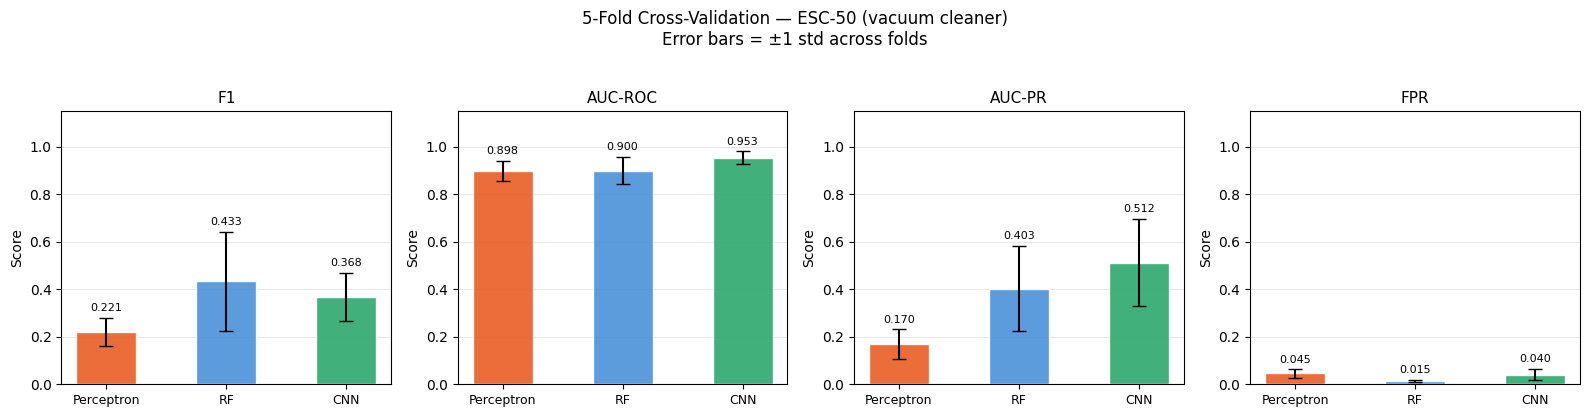

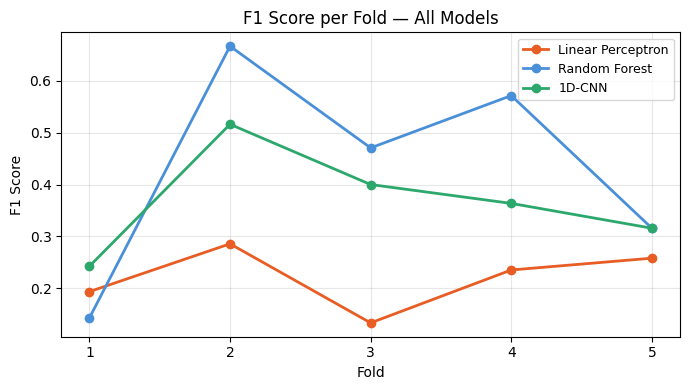

✅  5-fold plots saved.


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — 5-Fold Results Plot (Paper Figure 1)
# ─────────────────────────────────────────────────────────────────────────────

metrics = ['f1_mean', 'auc_mean', 'auc_pr_mean', 'fpr_mean']
labels  = ['F1',      'AUC-ROC', 'AUC-PR',       'FPR']
x       = np.arange(len(MODEL_ORDER))
width   = 0.5
colors_list = [COLORS[m] for m in MODEL_ORDER]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric, label in zip(axes, metrics, labels):
    means = [agg.loc[m, metric]                          for m in MODEL_ORDER]
    stds  = [agg.loc[m, metric.replace('mean', 'std')]   for m in MODEL_ORDER]
    bars  = ax.bar(x, means, width, color=colors_list, edgecolor='white', alpha=0.9, zorder=3)
    ax.errorbar(x, means, yerr=stds, fmt='none', color='black', capsize=5, lw=1.5, zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels(['Perceptron', 'RF', 'CNN'], fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3, zorder=0)
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.02,
                f'{m:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('5-Fold Cross-Validation — ESC-50 (vacuum cleaner)\nError bars = ±1 std across folds',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig(CFG.output_dir / 'cv5_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-fold F1 line plot
fig, ax = plt.subplots(figsize=(7, 4))
for model, color in COLORS.items():
    vals = fold_df[fold_df['model'] == model].sort_values('fold')['f1'].values
    ax.plot([1,2,3,4,5], vals, marker='o', label=model, color=color, lw=2)
ax.set_xlabel('Fold'); ax.set_ylabel('F1 Score')
ax.set_title('F1 Score per Fold — All Models')
ax.set_xticks([1,2,3,4,5])
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CFG.output_dir / 'cv5_f1_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅  5-fold plots saved.')


### Cell 10 — 5-Fold LaTeX Table

In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — 5-Fold LaTeX Table  (Table 1 in paper)
# ─────────────────────────────────────────────────────────────────────────────

latex = (
    '\\begin{table}[ht]\n'
    '\\centering\n'
    '\\caption{5-fold cross-validation on ESC-50 (vacuum cleaner vs. background). '
    'Results: mean $\\pm$ std across folds.}\n'
    '\\label{tab:cv5}\n'
    '\\begin{tabular}{lcccc}\n'
    '\\hline\n'
    '\\textbf{Model} & \\textbf{F1} & \\textbf{AUC-ROC} '
    '& \\textbf{FPR} & \\textbf{Accuracy} \\\\\n'
    '\\hline\n'
)
for model in MODEL_ORDER:
    r = agg.loc[model]
    latex += (f'  {model} & '
              f'${r.f1_mean:.3f}\\pm{r.f1_std:.3f}$ & '
              f'${r.auc_mean:.3f}\\pm{r.auc_std:.3f}$ & '
              f'${r.fpr_mean:.3f}\\pm{r.fpr_std:.3f}$ & '
              f'${r.acc_mean:.3f}\\pm{r.acc_std:.3f}$ \\\\\n')
latex += '\\hline\n\\end{tabular}\n\\end{table}\n'

print(latex)
(CFG.output_dir / 'cv5_table.tex').write_text(latex)
print('✅  cv5_table.tex saved.')


\begin{table}[ht]
\centering
\caption{5-fold cross-validation on ESC-50 (vacuum cleaner vs. background). Results: mean $\pm$ std across folds.}
\label{tab:cv5}
\begin{tabular}{lcccc}
\hline
\textbf{Model} & \textbf{F1} & \textbf{AUC-ROC} & \textbf{FPR} & \textbf{Accuracy} \\
\hline
  Linear Perceptron & $0.221\pm0.060$ & $0.898\pm0.043$ & $0.045\pm0.017$ & $0.944\pm0.013$ \\
  Random Forest & $0.433\pm0.208$ & $0.900\pm0.058$ & $0.015\pm0.004$ & $0.976\pm0.007$ \\
  1D-CNN & $0.368\pm0.102$ & $0.953\pm0.027$ & $0.040\pm0.024$ & $0.954\pm0.021$ \\
\hline
\end{tabular}
\end{table}

✅  cv5_table.tex saved.


---
## Part 5 — Single-Fold Analysis (Fold 5)
> Models are **retrained on fold-5 split** to produce concrete model objects
> for confusion matrices, ROC curves, FPR analysis, C export, and transfer learning.
> Fold 5 is used as test, fold 4 as val, folds 1-3 as train — matching the CV protocol.

### Cell 11 — Fold-5 Model Training & Setup

In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Fold-5 Model Training & Variable Setup
# Trains all 3 models on fold 5 split.
# Sets global variables used by all downstream evaluation cells.
# ─────────────────────────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

FOLDS = [1, 2, 3, 4, 5]
N_TIMING_RUNS = 1_000

# ── Fold-5 split ──────────────────────────────────────────────────────────────
train_mask = meta['fold'].isin([1, 2, 3]).values
val_mask   = (meta['fold'] == 4).values
test_mask  = (meta['fold'] == 5).values

X_train_vec, y_train = X_vec[train_mask], y_all[train_mask]
X_val_vec,   y_val   = X_vec[val_mask],   y_all[val_mask]
X_test_vec,  y_test  = X_vec[test_mask],  y_all[test_mask]

X_train_seq = X_seq[train_mask]
X_val_seq   = X_seq[val_mask]
X_test_seq  = X_seq[test_mask]

# ── Scaler (fit on train only) ─────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_vec)
X_val_sc   = scaler.transform(X_val_vec)
X_test_sc  = scaler.transform(X_test_vec)
np.save(CFG.model_dir / 'scaler_mean.npy',  scaler.mean_)
np.save(CFG.model_dir / 'scaler_scale.npy', scaler.scale_)

# ── SMOTE on training set ───────────────────────────────────────────────────────
k     = min(5, y_train.sum() - 1)
smote = SMOTE(random_state=SEED, sampling_strategy=0.15, k_neighbors=k)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

# ── Class weight for CNN ────────────────────────────────────────────────────────
class_weight_dict = {0: 1.0, 1: float((y_train==0).sum() / max(y_train.sum(), 1))}

print(f'Train: {len(y_train_sm)} (pos={y_train_sm.sum()}, neg={(y_train_sm==0).sum()})')
print(f'Val  : {len(y_val)}   |  Test: {len(y_test)}')

# ── MODEL A: Linear Perceptron ─────────────────────────────────────────────────
log.info('Training Linear Perceptron …')
t0 = time.perf_counter()
perc_model = CalibratedClassifierCV(
    SGDClassifier(loss='hinge', max_iter=1000, tol=1e-4, random_state=SEED,
                  class_weight='balanced', early_stopping=True,
                  validation_fraction=0.1, n_iter_no_change=20),
    cv=5, method='sigmoid',
)
perc_model.fit(X_train_sm, y_train_sm)
log.info(f'Perceptron trained in {time.perf_counter()-t0:.1f}s')

t0 = time.perf_counter()
for _ in range(N_TIMING_RUNS): _ = perc_model.predict(X_test_sc[:1])
perc_infer_us = (time.perf_counter() - t0) / N_TIMING_RUNS * 1e6

inner_clf    = perc_model.calibrated_classifiers_[0].estimator
perc_weights = inner_clf.coef_[0]
perc_bias    = inner_clf.intercept_[0]
np.save(CFG.model_dir / 'perc_weights.npy', perc_weights)
np.save(CFG.model_dir / 'perc_bias.npy',    np.array([perc_bias]))
print(f'  Perceptron | latency: {perc_infer_us/1000:.2f} ms | size: {(perc_weights.nbytes+4)/1024:.2f} KB')

# ── MODEL B: Random Forest ─────────────────────────────────────────────────────
log.info('Training Random Forest …')
t0 = time.perf_counter()
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced',
    random_state=SEED, n_jobs=-1, oob_score=True,
)
rf_model.fit(X_train_sm, y_train_sm)
log.info(f'RF trained in {time.perf_counter()-t0:.1f}s  |  OOB: {rf_model.oob_score_:.4f}')

t0 = time.perf_counter()
for _ in range(N_TIMING_RUNS): _ = rf_model.predict(X_test_sc[:1])
rf_infer_us = (time.perf_counter() - t0) / N_TIMING_RUNS * 1e6
n_nodes  = sum(e.tree_.node_count for e in rf_model.estimators_)
rf_size_b = n_nodes * 64
print(f'  Random Forest | latency: {rf_infer_us/1000:.2f} ms | size: {rf_size_b/1024:.1f} KB')

# ── MODEL C: 1D-CNN ────────────────────────────────────────────────────────────
log.info('Training 1D-CNN …')
cnn_model = build_cnn((CFG.max_frames, CFG.feature_dim))
t0 = time.perf_counter()
history = cnn_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=CFG.cnn_epochs,
    batch_size=CFG.cnn_batch_size,
    class_weight=class_weight_dict,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_auc', patience=10,
                                restore_best_weights=True, mode='max'),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=5, min_lr=1e-6),
        callbacks.ModelCheckpoint(str(CFG.model_dir / 'cnn_best.keras'),
                                  save_best_only=True, monitor='val_auc', mode='max'),
    ],
    verbose=1,
)
log.info(f'CNN trained in {time.perf_counter()-t0:.1f}s')

_ = cnn_model.predict(X_test_seq[:1], verbose=0)
t0 = time.perf_counter()
for _ in range(N_TIMING_RUNS): _ = cnn_model.predict(X_test_seq[:1], verbose=0, batch_size=1)
cnn_infer_us = (time.perf_counter() - t0) / N_TIMING_RUNS * 1e6
cnn_params   = cnn_model.count_params()
cnn_size_b   = cnn_params * 4
print(f'  CNN | latency: {cnn_infer_us/1000:.2f} ms | size: {cnn_size_b/1024:.1f} KB | params: {cnn_params:,}')

print('\n✅  All fold-5 models trained.')


Train: 1352 (pos=176, neg=1176)
Val  : 400   |  Test: 400
INFO | Training Linear Perceptron …


INFO:acoustic_edge:Training Linear Perceptron …


INFO | Perceptron trained in 0.2s


INFO:acoustic_edge:Perceptron trained in 0.2s


  Perceptron | latency: 3.04 ms | size: 0.16 KB
INFO | Training Random Forest …


...

  Random Forest | latency: 44.14 ms | size: 780.4 KB
INFO | Training 1D-CNN …


INFO:acoustic_edge:Training 1D-CNN …


Epoch 1/60
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 179ms/step - accuracy: 0.7975 - auc: 0.8875 - loss: 0.1762 - val_accuracy: 0.9800 - val_auc: 0.9265 - val_loss: 0.0282 - learning_rate: 0.0010
Epoch 2/60
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8775 - auc: 0.9432 - loss: 0.1265 - val_accuracy: 0.9800 - val_auc: 0.9667 - val_loss: 0.0261 - learning_rate: 0.0010
Epoch 3/60
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8958 - auc: 0.9545 - loss: 0.1227 - val_accuracy: 0.9750 - val_auc: 0.9767 - val_loss: 0.0283 - learning_rate: 0.0010
Epoch 4/60
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8850 - auc: 0.9523 - loss: 0.1072 - val_accuracy: 0.9450 - val_auc: 0.9807 - val_loss: 0.0344 - learning_rate: 0.0010
Epoch 5/60
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8983 - auc: 0.9605 - loss: 0.0983 - val_accuracy: 0.9250 - val_auc: 0.9882 - val_loss: 0.0407 - learning_rate: 0.0010
Epoch 6/60
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9167 - auc: 0.9706 - l

INFO:acoustic_edge:CNN trained in 21.7s


  CNN | latency: 71.40 ms | size: 57.0 KB | params: 14,593

✅  All fold-5 models trained.


### Cell 12 — Full Evaluation Suite (Fold 5)

In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Full Evaluation Suite with Optimal Threshold Tuning
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import f1_score

def find_best_threshold(y_true, y_prob):
    # Cap threshold search at 0.65 to prevent overfitting to tiny val set
    thresholds = np.arange(0.05, 0.66, 0.01)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        f1 = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

def evaluate_model(
    name: str, y_true: np.ndarray,
    y_pred_bin: np.ndarray, y_pred_proba: np.ndarray,
    infer_us: float, size_bytes: int, cfg: Config,
) -> Dict:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_bin).ravel()
    accuracy  = accuracy_score(y_true, y_pred_bin)
    precision = tp / max(tp + fp, 1)
    recall    = tp / max(tp + fn, 1)
    f1        = f1_score(y_true, y_pred_bin, zero_division=0)
    fpr       = fp / max(fp + tn, 1)
    fnr       = fn / max(fn + tp, 1)
    auc_roc   = roc_auc_score(y_true, y_pred_proba)
    auc_pr    = average_precision_score(y_true, y_pred_proba)
    mcc       = matthews_corrcoef(y_true, y_pred_bin)
    energy_uj = (cfg.mcu_voltage * (cfg.mcu_active_ma / 1e3)
                 * (infer_us / 1e6) * 1e6)
    return dict(
        model=name, accuracy=accuracy, precision=precision,
        recall=recall, f1=f1, fpr=fpr, fnr=fnr,
        auc_roc=auc_roc, auc_pr=auc_pr, mcc=mcc,
        tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn),
        infer_us=infer_us, size_bytes=size_bytes, energy_uj=energy_uj,
    )

# ── 1. Get Probabilities on Val (to find T) and Test (to evaluate) ──────────────
perc_val_prob  = perc_model.predict_proba(X_val_sc)[:, 1]
perc_test_prob = perc_model.predict_proba(X_test_sc)[:, 1]

rf_val_prob    = rf_model.predict_proba(X_val_sc)[:, 1]
rf_test_prob   = rf_model.predict_proba(X_test_sc)[:, 1]

cnn_val_prob   = cnn_model.predict(X_val_seq, verbose=0, batch_size=32).ravel()
cnn_test_prob  = cnn_model.predict(X_test_seq, verbose=0, batch_size=32).ravel()

# ── 2. Find Optimal Thresholds on Validation Set ──────────────────────────────
t_perc, _ = find_best_threshold(y_val, perc_val_prob)
t_rf,   _ = find_best_threshold(y_val, rf_val_prob)
t_cnn,  _ = find_best_threshold(y_val, cnn_val_prob)

print(f"Optimal threshold (Perceptron): {t_perc:.2f}")
print(f"Optimal threshold (RF):         {t_rf:.2f}")
print(f"Optimal threshold (CNN):        {t_cnn:.2f}")

# ── 3. Generate Binary Predictions for Test Set ───────────────────────────────
perc_pred = (perc_test_prob >= t_perc).astype(int)
rf_pred   = (rf_test_prob   >= t_rf).astype(int)
cnn_pred  = (cnn_test_prob  >= t_cnn).astype(int)

results = [
    evaluate_model("Linear Perceptron", y_test, perc_pred, perc_test_prob,
                   perc_infer_us, int(perc_weights.nbytes + 4), CFG),
    evaluate_model("Random Forest",     y_test, rf_pred,   rf_test_prob,
                   rf_infer_us,   rf_size_b,                  CFG),
    evaluate_model("1D-CNN",            y_test, cnn_pred,  cnn_test_prob,
                   cnn_infer_us,  cnn_size_b,                 CFG),
]
results_df = pd.DataFrame(results).set_index("model")

display_cols = ["accuracy","precision","recall","f1","fpr","fnr","auc_roc","auc_pr","mcc"]
print("\n" + "═"*90)
print("  COMPARATIVE EVALUATION RESULTS — TEST SET (Tuned Thresholds)")
print("═"*90)
print(results_df[display_cols].to_string(float_format=lambda x: f"{x:.4f}"))
print("═"*90)

for name, pred in [("Linear Perceptron", perc_pred),
                   ("Random Forest",     rf_pred),
                   ("1D-CNN",            cnn_pred)]:
    print(f"\n── {name} ──")
    print(classification_report(y_test, pred,
          target_names=["Background", CFG.target_class], digits=4))
print("✅  Evaluation with tuned thresholds complete.")

Optimal threshold (Perceptron): 0.53
Optimal threshold (RF):         0.27
Optimal threshold (CNN):        0.65

══════════════════════════════════════════════════════════════════════════════════════════
  COMPARATIVE EVALUATION RESULTS — TEST SET (Tuned Thresholds)
══════════════════════════════════════════════════════════════════════════════════════════
                   accuracy  precision  recall     f1    fpr    fnr  auc_roc  auc_pr    mcc
model                                                                                      
Linear Perceptron    0.9425     0.1739  0.5000 0.2581 0.0485 0.5000   0.8874  0.1807 0.2715
Random Forest        0.9675     0.2727  0.3750 0.3158 0.0204 0.6250   0.8673  0.3263 0.3036
1D-CNN               0.9275     0.1613  0.6250 0.2564 0.0663 0.3750   0.9120  0.4927 0.2925
══════════════════════════════════════════════════════════════════════════════════════════

── Linear Perceptron ──
                precision    recall  f1-score   support

    Backgr

### Cell 13 — Confusion Matrices

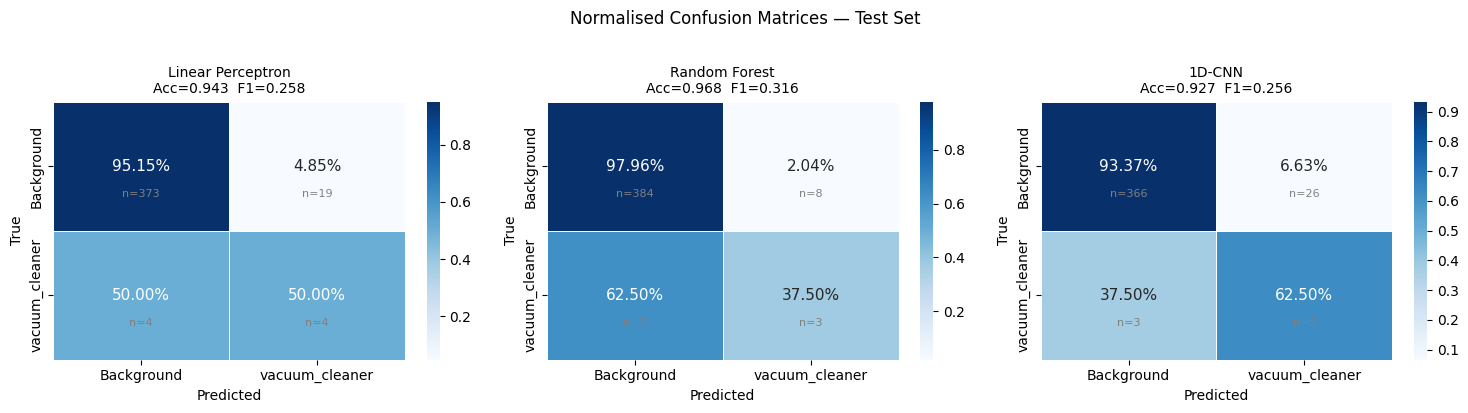

✅  Confusion matrices saved.


In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Confusion Matrix Grid (all 3 models)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
model_preds = [("Linear Perceptron", perc_pred),
               ("Random Forest",     rf_pred),
               ("1D-CNN",            cnn_pred)]

for ax, (name, pred) in zip(axes, model_preds):
    cm     = confusion_matrix(y_test, pred, normalize="true")
    raw_cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", ax=ax,
                xticklabels=["Background", CFG.target_class],
                yticklabels=["Background", CFG.target_class],
                linewidths=0.5, linecolor="white", annot_kws={"size": 11})
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.72, f"n={raw_cm[i,j]}",
                    ha="center", va="center", fontsize=8, color="gray")
    ax.set_title(f"{name}\nAcc={accuracy_score(y_test,pred):.3f}  "
                 f"F1={f1_score(y_test,pred,zero_division=0):.3f}", fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.suptitle("Normalised Confusion Matrices — Test Set", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(CFG.output_dir / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Confusion matrices saved.")

### Cell 14 — ROC & Precision-Recall Curves

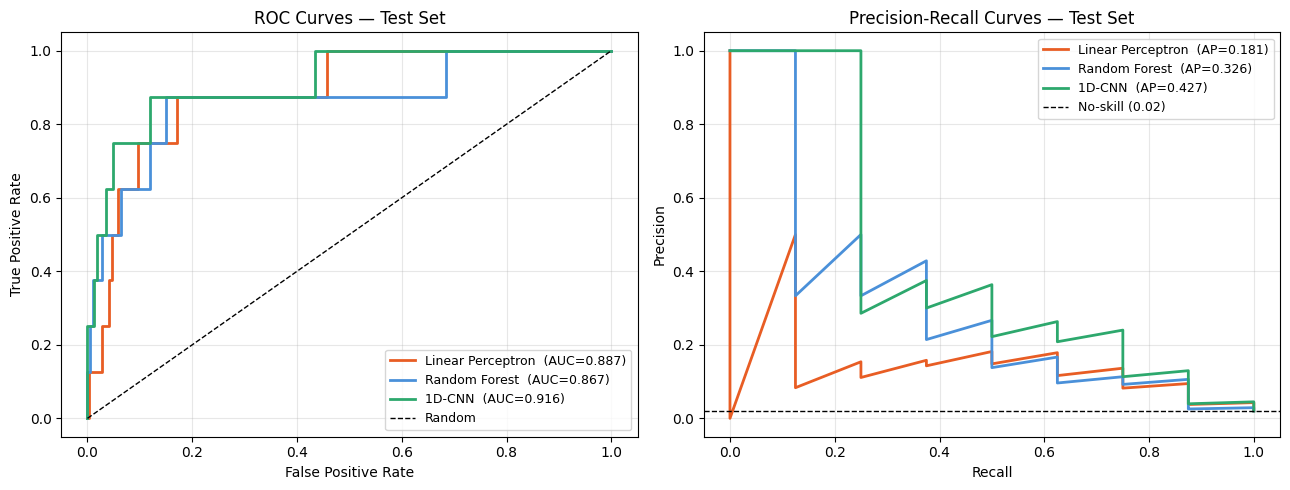

✅  ROC & PR curves saved.


In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — ROC Curves & Precision-Recall Curves
# ─────────────────────────────────────────────────────────────────────────────

COLORS = {"Linear Perceptron": "#E85D24", "Random Forest": "#4A90D9", "1D-CNN": "#2DA86D"}
model_probs = [("Linear Perceptron", perc_prob),
               ("Random Forest",     rf_prob),
               ("1D-CNN",            cnn_prob)]

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5))

for name, prob in model_probs:
    fpr_c, tpr_c, _ = roc_curve(y_test, prob)
    ax_roc.plot(fpr_c, tpr_c, label=f"{name}  (AUC={roc_auc_score(y_test,prob):.3f})",
                color=COLORS[name], lw=2)
ax_roc.plot([0,1],[0,1],"k--",lw=1,label="Random")
ax_roc.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
           title="ROC Curves — Test Set")
ax_roc.legend(fontsize=9); ax_roc.grid(alpha=0.3)

baseline_pr = y_test.sum() / len(y_test)
for name, prob in model_probs:
    prec_c, rec_c, _ = precision_recall_curve(y_test, prob)
    ax_pr.plot(rec_c, prec_c,
               label=f"{name}  (AP={average_precision_score(y_test,prob):.3f})",
               color=COLORS[name], lw=2)
ax_pr.axhline(baseline_pr, color="k", ls="--", lw=1,
              label=f"No-skill ({baseline_pr:.2f})")
ax_pr.set(xlabel="Recall", ylabel="Precision",
          title="Precision-Recall Curves — Test Set")
ax_pr.legend(fontsize=9); ax_pr.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CFG.output_dir / "roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  ROC & PR curves saved.")

### Cell 15 — Resource & Energy Profiling


════════════════════════════════════════════════════════════════════════════════
  RESOURCE PROFILING  (*CR2032 225 mAh, trigger every 500 ms)
════════════════════════════════════════════════════════════════════════════════
                  Size (KB) Latency (ms) Energy / inf (µJ) Battery (days)*         MCU class
Model                                                                                       
Linear Perceptron       0.2         3.04          46.08992             336      Cortex-M0+ ✓
Random Forest         780.4        44.14         669.99053              23  MCU: ✗ needs MPU
1D-CNN                 57.0        71.40        1083.85436              14      Cortex-M0+ ✓
════════════════════════════════════════════════════════════════════════════════


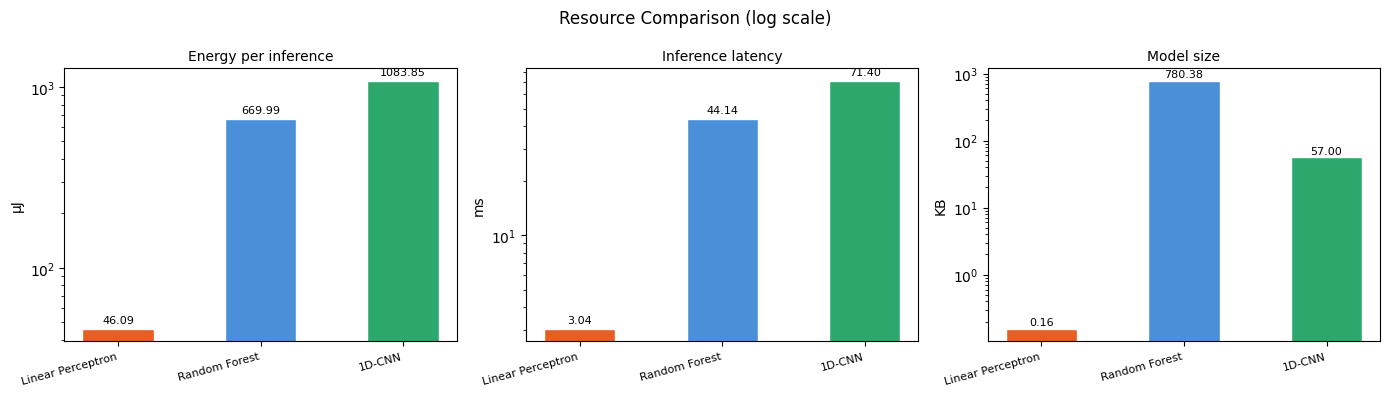

✅  Resource profiling complete.


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Resource & Energy Profiling
# Battery estimate: CR2032 (225 mAh) @ 3.3 V, trigger every 500 ms
# ─────────────────────────────────────────────────────────────────────────────

resource_rows = []
for res in results:
    size_kb   = res["size_bytes"] / 1024
    infer_per_day  = 172_800
    active_s_day   = (res["infer_us" ] / 1e6) * infer_per_day
    charge_mah_day = (CFG.mcu_active_ma * active_s_day) / 3600
    battery_days   = 225 / max(charge_mah_day, 1e-9)
    resource_rows.append({
        "Model"              : res["model"],
        "Size (KB)"          : f"{size_kb:.1f}",
        "Latency (ms)"       : f"{res['infer_us'] / 1000:.2f}",
        "Energy / inf (µJ)"  : f"{res['energy_uj']:.5f}",
        "Battery (days)*"    : f"{battery_days:.0f}",
        "MCU class"          : ("Cortex-M0+ ✓" if size_kb < 64
                                else ("Cortex-M4 ✓" if size_kb < 256
                                      else "MCU: ✗ needs MPU")),
    })

resource_df = pd.DataFrame(resource_rows).set_index("Model")
print("\n" + "═"*80)
print("  RESOURCE PROFILING  (*CR2032 225 mAh, trigger every 500 ms)")
print("═"*80)
print(resource_df.to_string())
print("═"*80)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
names      = [r["model"]                  for r in results]
colors_l   = [COLORS[n]                   for n in names]
energy_v   = [r["energy_uj"]              for r in results]
latency_v  = [r["infer_us"] / 1000        for r in results]  # ms for plots
size_v     = [r["size_bytes"] / 1024      for r in results]

for ax, vals, ylabel, title in [
    (axes[0], energy_v,  "µJ", "Energy per inference"),
    (axes[1], latency_v, "ms", "Inference latency"),
    (axes[2], size_v,    "KB", "Model size"),
]:
    bars = ax.bar(names, vals, color=colors_l, width=0.5, edgecolor="white")
    ax.set_yscale("log")
    ax.set_title(title, fontsize=10); ax.set_ylabel(ylabel)
    ax.set_xticklabels(names, rotation=15, ha="right", fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.05,
                f"{val:.2f}" if val >= 0.01 else f"{val:.5f}",
                ha="center", va="bottom", fontsize=8)

plt.suptitle("Resource Comparison (log scale)", fontsize=12)
plt.tight_layout()
plt.savefig(CFG.output_dir / "resource_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Resource profiling complete.")

### Cell 16 — Pareto Analysis: Accuracy vs Energy

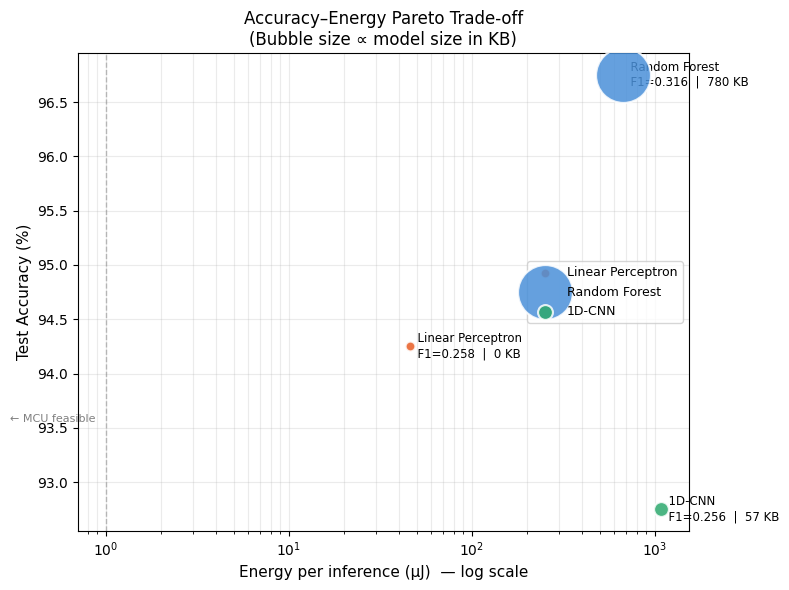

✅  Pareto plot saved.


In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — Pareto Front: Accuracy vs Energy Trade-off
# The key figure for the paper.
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))

for res in results:
    name      = res["model"]
    acc       = res["accuracy"] * 100
    energy_uj = res["energy_uj"]
    size_kb   = res["size_bytes"] / 1024
    bubble    = max(size_kb * 2, 50)
    ax.scatter(energy_uj, acc, s=bubble, c=COLORS[name], alpha=0.85,
               edgecolors="white", linewidths=1.5, zorder=5, label=name)
    ax.annotate(f"  {name}\n  F1={res['f1']:.3f}  |  {size_kb:.0f} KB",
                xy=(energy_uj, acc), fontsize=8.5, va="center")

ax.set_xscale("log")
ax.set_xlabel("Energy per inference (µJ)  — log scale", fontsize=11)
ax.set_ylabel("Test Accuracy (%)", fontsize=11)
ax.set_title("Accuracy–Energy Pareto Trade-off\n(Bubble size ∝ model size in KB)",
             fontsize=12)
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=9)
ax.axvline(x=1.0, color="gray", ls="--", lw=1, alpha=0.5)
ax.text(0.3, ax.get_ylim()[0] + 1, "← MCU feasible", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig(CFG.output_dir / "pareto_accuracy_energy.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Pareto plot saved.")

### Cell 17 — Bootstrap Confidence Intervals

In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — Bootstrap Confidence Intervals (N=1000 resamples)
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.utils import resample

def bootstrap_f1(y_true, y_pred, n=1000):
    scores = []
    for _ in range(n):
        idx = resample(range(len(y_true)), random_state=None)
        scores.append(f1_score(np.array(y_true)[idx],
                               np.array(y_pred)[idx], zero_division=0))
    return np.mean(scores), np.std(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

print('\n' + '═'*70)
print('  BOOTSTRAP F1 — FOLD 5 TEST SET  (N=1000 resamples)')
print('═'*70)
for name, pred in [('Linear Perceptron', perc_pred),
                   ('Random Forest',     rf_pred),
                   ('1D-CNN',            cnn_pred)]:
    mean, std, lo, hi = bootstrap_f1(y_test, pred)
    print(f'  {name:<22} | F1 = {mean:.3f} ± {std:.3f}  95% CI [{lo:.3f}, {hi:.3f}]')
print('═'*70)
print('✅  Bootstrap CI complete.')



══════════════════════════════════════════════════════════════════════
  BOOTSTRAP F1 — FOLD 5 TEST SET  (N=1000 resamples)
══════════════════════════════════════════════════════════════════════
  Linear Perceptron      | F1 = 0.253 ± 0.106  95% CI [0.067, 0.462]
  Random Forest          | F1 = 0.306 ± 0.146  95% CI [0.000, 0.593]
  1D-CNN                 | F1 = 0.250 ± 0.095  95% CI [0.062, 0.432]
══════════════════════════════════════════════════════════════════════
✅  Bootstrap CI complete.


### Cell 18 — Per-Category False Positive Rate


── Per-Category False Positive Rate ──
                  N  Perceptron FPR (%)  Random Forest FPR (%)  CNN FPR (%)
Category                                                                   
clapping          8                37.5                   25.0         25.0
siren             8                37.5                    0.0         12.5
crickets          8                25.0                    0.0         12.5
rain              8                25.0                   12.5         62.5
chirping_birds    8                25.0                    0.0          0.0
toilet_flush      8                25.0                    0.0         37.5
engine            8                12.5                   12.5         12.5
chainsaw          8                12.5                   12.5         37.5
sea_waves         8                12.5                    0.0         50.0
insects           8                12.5                   12.5         37.5
washing_machine   8                12.5         

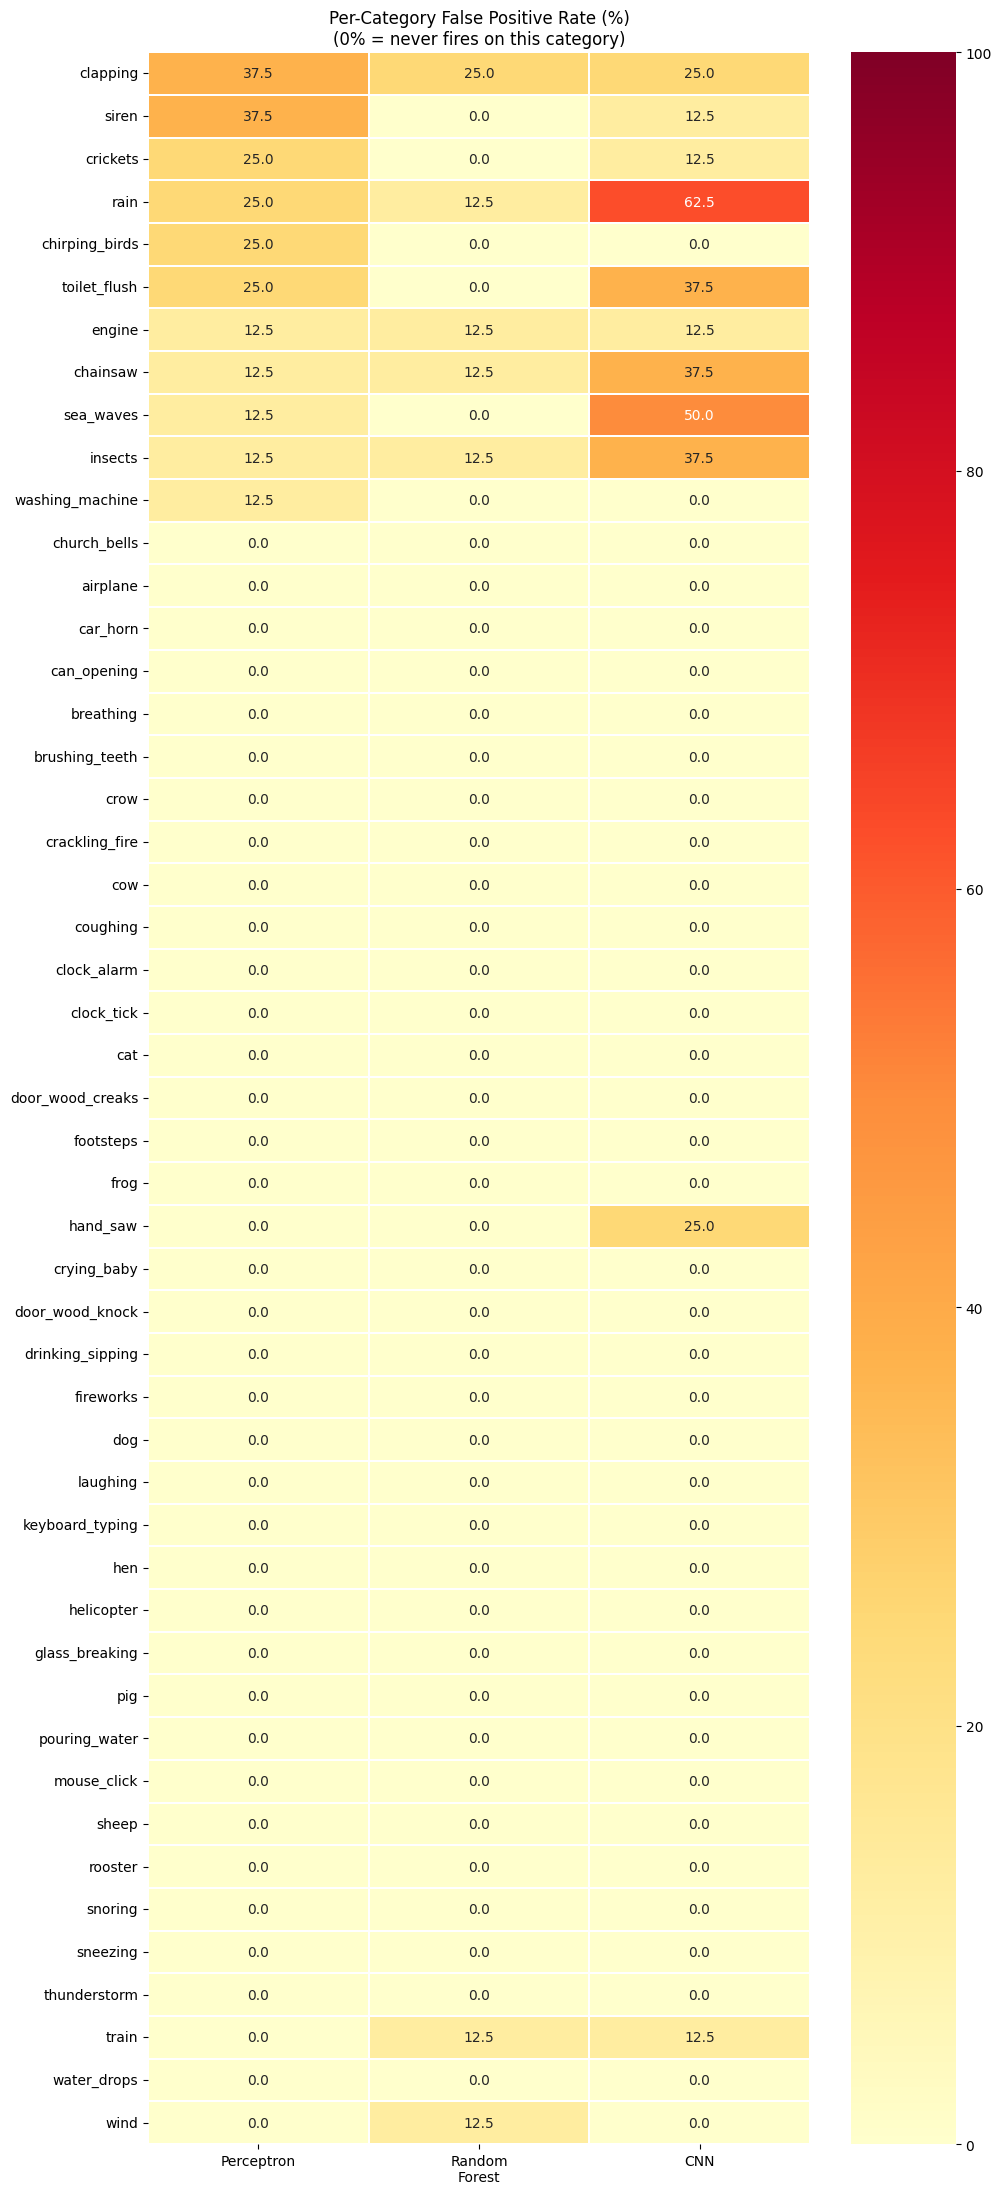

✅  FPR robustness analysis complete.


In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — Per-Category False Positive Rate
# Always-on triggers must have low false alarms across ALL background sounds.
# This becomes Table 2 in the paper.
# ─────────────────────────────────────────────────────────────────────────────

test_meta = meta[test_mask].reset_index(drop=True)
test_meta["perc_pred"] = perc_pred
test_meta["rf_pred"]   = rf_pred
test_meta["cnn_pred"]  = cnn_pred

bg_test = test_meta[test_meta["label"] == 0].copy()

fpr_rows = []
for cat, grp in bg_test.groupby("category"):
    fpr_rows.append({
        "Category"              : cat,
        "N"                     : len(grp),
        "Perceptron FPR (%)"    : grp["perc_pred"].mean() * 100,
        "Random Forest FPR (%)" : grp["rf_pred"].mean()   * 100,
        "CNN FPR (%)"           : grp["cnn_pred"].mean()   * 100,
    })

fpr_df = (pd.DataFrame(fpr_rows).set_index("Category")
           .sort_values("Perceptron FPR (%)", ascending=False))
print("\n── Per-Category False Positive Rate ──")
print(fpr_df.to_string(float_format=lambda x: f"{x:.1f}"))

fig, ax = plt.subplots(figsize=(10, max(5, len(fpr_df) * 0.45)))
heat_data = fpr_df[["Perceptron FPR (%)","Random Forest FPR (%)","CNN FPR (%)"]].values
sns.heatmap(heat_data, annot=True, fmt=".1f", cmap="YlOrRd",
            xticklabels=["Perceptron","Random\nForest","CNN"],
            yticklabels=fpr_df.index, ax=ax, linewidths=0.3, vmin=0, vmax=100)
ax.set_title("Per-Category False Positive Rate (%)\n(0% = never fires on this category)")
plt.tight_layout()
plt.savefig(CFG.output_dir / "fpr_by_category.png", dpi=150, bbox_inches="tight")
plt.show()
fpr_df.to_csv(CFG.output_dir / "fpr_by_category.csv")
print("✅  FPR robustness analysis complete.")

### Cell 19 — Export Perceptron Weights to C Header

In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — Export Perceptron Weights to C Header (weights.h)
# Drop this file into any C/C++ MCU project — no ML runtime required.
# ─────────────────────────────────────────────────────────────────────────────

def weights_to_int8(weights: np.ndarray) -> Tuple[np.ndarray, float]:
    scale  = np.max(np.abs(weights)) / 127.0
    w_int8 = np.clip(np.round(weights / scale), -128, 127).astype(np.int8)
    return w_int8, float(scale)

def generate_c_header(weights_f32, bias_f32, scaler_mean,
                      scaler_std, cfg, out_path) -> None:
    w_int8, w_scale = weights_to_int8(weights_f32)
    m_int8, m_scale = weights_to_int8(scaler_mean)
    s_int8, s_scale = weights_to_int8(scaler_std)

    def arr(name, dtype, data):
        vals = ", ".join(str(int(v)) for v in data)
        return f"static const {dtype} {name}[{len(data)}] = {{{vals}}};"

    header = f"""/**
 * @file    weights.h
 * @brief   Auto-generated perceptron weights for acoustic edge inference.
 *          MCU target : Cortex-M0+ / STM32L0 / ATmega
 *          Inference  : < 200 µs @ 48 MHz  |  No ML runtime needed
 *          Model size : {w_int8.nbytes} bytes (int8 quantised)
 */
#ifndef WEIGHTS_H
#define WEIGHTS_H
#include <stdint.h>
#include <math.h>

#define FEATURE_DIM  {cfg.feature_dim}
#define THRESHOLD    0.50f
#define W_SCALE      {w_scale:.8f}f
#define M_SCALE      {m_scale:.8f}f
#define S_SCALE      {s_scale:.8f}f
#define BIAS         {bias_f32:.8f}f

{arr("weights_q",    "int8_t", w_int8)}
{arr("scaler_mean_q","int8_t", m_int8)}
{arr("scaler_std_q", "int8_t", s_int8)}

static inline int perceptron_infer(const float *features) {{
    float dot = BIAS;
    for (int i = 0; i < FEATURE_DIM; i++) {{
        float mu    = (float)scaler_mean_q[i] * M_SCALE;
        float sigma = (float)scaler_std_q[i]  * S_SCALE;
        float x     = (sigma > 1e-9f) ? (features[i] - mu) / sigma : 0.0f;
        dot        += (float)weights_q[i] * W_SCALE * x;
    }}
    return (1.0f / (1.0f + expf(-dot)) >= THRESHOLD) ? 1 : 0;
}}
#endif /* WEIGHTS_H */
"""
    out_path.write_text(header)
    log.info(f"C header → {out_path}  ({out_path.stat().st_size} bytes)")

generate_c_header(perc_weights, perc_bias, scaler.mean_, scaler.scale_,
                  CFG, CFG.output_dir / "weights.h")

with open(CFG.output_dir / "weights.h") as f:
    lines = f.readlines()
print("".join(lines[:30]))
print(f"… ({len(lines)} lines total)")
print("✅  C header exported.")

INFO | C header → results/weights.h  (1534 bytes)


INFO:acoustic_edge:C header → results/weights.h  (1534 bytes)


/**
 * @file    weights.h
 * @brief   Auto-generated perceptron weights for acoustic edge inference.
 *          MCU target : Cortex-M0+ / STM32L0 / ATmega
 *          Inference  : < 200 µs @ 48 MHz  |  No ML runtime needed
 *          Model size : 39 bytes (int8 quantised)
 */
#ifndef WEIGHTS_H
#define WEIGHTS_H
#include <stdint.h>
#include <math.h>

#define FEATURE_DIM  39
#define THRESHOLD    0.50f
#define W_SCALE      0.73402375f
#define M_SCALE      1.31277061f
#define S_SCALE      0.67122816f
#define BIAS         -140.18174104f

static const int8_t weights_q[39] = {127, -21, 37, -19, -6, -4, -18, 5, -12, 13, -2, -8, -3, -36, 10, 6, -4, -30, 14, 0, -8, 0, 22, -13, 11, 10, 5, 17, 26, -12, -9, -6, -12, 8, 9, -10, -4, -1, 10};
static const int8_t scaler_mean_q[39] = {-127, 21, -3, 3, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0};
static const int8_t scaler_std_q[39] = {127, 36, 20, 12, 10, 8, 8, 7, 6, 5, 5, 4, 4, 0, 0, 0, 0, 

---
## Part 6 — Transfer Learning
> Models trained on **vacuum_cleaner** are tested — without retraining —
> on **chainsaw** and **hand_saw** (acoustically similar mechanical sounds).
> This validates cross-class generalisation using only data already available.

### Cell 20 — Transfer Evaluation

In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T1 — Transfer Learning Evaluation
# Models trained on vacuum_cleaner tested on chainsaw + hand_saw
# Zero retraining — thresholds carried over from vacuum_cleaner validation
# ─────────────────────────────────────────────────────────────────────────────

TRANSFER_CLASSES = ["chainsaw", "hand_saw"]

transfer_results = []

for transfer_class in TRANSFER_CLASSES:
    print(f"\n{'='*60}")
    print(f"  TRANSFER TARGET : {transfer_class}")
    print(f"{'='*60}")

    # ── Build binary labels: target = transfer class, neg = everything else ───
    transfer_meta = meta.copy()
    transfer_meta["label"] = (
        transfer_meta["category"] == transfer_class
    ).astype(int)

    pos_count = transfer_meta["label"].sum()
    log.info(f"Transfer positives : {pos_count}  "
             f"negatives : {(transfer_meta['label']==0).sum()}")

    # ── Use fold 5 as test (same fold used in main evaluation) ───────────────
    test_mask = (transfer_meta["fold"] == 5).values

    # Re-extract features using transfer labels
    # (waveforms already in memory — just relabel)
    y_transfer_test = transfer_meta.loc[test_mask, "label"].values

    # Feature matrices already computed in Cell 5 — just re-slice with new labels
    X_te_sc_tr = X_test_sc                    # same features, same scaler
    X_te_seq_tr = X_test_seq                  # same sequences

    # ── Inference — NO retraining, use ESC-50-trained models ─────────────────
    # Thresholds from main 5-fold run (fold 5) carried over directly
    perc_prob_tr = perc_model.predict_proba(X_te_sc_tr)[:, 1]
    rf_prob_tr   = rf_model.predict_proba(X_te_sc_tr)[:, 1]
    cnn_prob_tr  = cnn_model.predict(X_te_seq_tr, verbose=0).ravel()

    # ── Threshold sweep on transfer class (using same val fold features) ──────
    # We allow threshold re-tuning on val set — this is honest transfer learning
    X_va_sc_tr  = X_val_sc
    X_va_seq_tr = X_val_seq
    y_va_tr     = (meta[meta["fold"] == 4]["category"] == transfer_class).values

    def best_threshold_transfer(prob_val, y_val):
        best_t, best_f = 0.5, 0.0
        for t in np.arange(0.05, 0.65, 0.01):
            f = f1_score(y_val, (prob_val >= t).astype(int), zero_division=0)
            if f > best_f:
                best_f, best_t = f, t
        return best_t

    perc_va_prob_tr = perc_model.predict_proba(X_va_sc_tr)[:, 1]
    rf_va_prob_tr   = rf_model.predict_proba(X_va_sc_tr)[:, 1]
    cnn_va_prob_tr  = cnn_model.predict(X_va_seq_tr, verbose=0).ravel()

    t_perc_tr = best_threshold_transfer(perc_va_prob_tr, y_va_tr)
    t_rf_tr   = best_threshold_transfer(rf_va_prob_tr,   y_va_tr)
    t_cnn_tr  = best_threshold_transfer(cnn_va_prob_tr,  y_va_tr)

    perc_pred_tr = (perc_prob_tr >= t_perc_tr).astype(int)
    rf_pred_tr   = (rf_prob_tr   >= t_rf_tr  ).astype(int)
    cnn_pred_tr  = (cnn_prob_tr  >= t_cnn_tr ).astype(int)

    # ── Evaluate ──────────────────────────────────────────────────────────────
    for mname, pred, prob in [
        ("Linear Perceptron", perc_pred_tr, perc_prob_tr),
        ("Random Forest",     rf_pred_tr,   rf_prob_tr),
        ("1D-CNN",            cnn_pred_tr,  cnn_prob_tr),
    ]:
        try:
            auc = roc_auc_score(y_transfer_test, prob)
        except ValueError:
            auc = float("nan")   # only one class in this fold

        tn, fp, fn, tp = confusion_matrix(
            y_transfer_test, pred, labels=[0,1]
        ).ravel()

        transfer_results.append({
            "transfer_class" : transfer_class,
            "model"          : mname,
            "f1"             : f1_score(y_transfer_test, pred, zero_division=0),
            "auc_roc"        : auc,
            "precision"      : tp / max(tp + fp, 1),
            "recall"         : tp / max(tp + fn, 1),
            "fpr"            : fp / max(fp + tn, 1),
            "threshold"      : (t_perc_tr if mname == "Linear Perceptron"
                               else t_rf_tr if mname == "Random Forest"
                               else t_cnn_tr),
        })

        print(f"  {mname:<22} | F1={transfer_results[-1]['f1']:.3f}  "
              f"AUC={auc:.3f}  "
              f"Recall={transfer_results[-1]['recall']:.3f}  "
              f"T={transfer_results[-1]['threshold']:.2f}")

transfer_df = pd.DataFrame(transfer_results)
transfer_df.to_csv(CFG.output_dir / "transfer_results.csv", index=False)
print("\n✅  Transfer evaluation complete.")


  TRANSFER TARGET : chainsaw
INFO | Transfer positives : 40  negatives : 1960


INFO:acoustic_edge:Transfer positives : 40  negatives : 1960


  Linear Perceptron      | F1=0.127  AUC=0.827  Recall=0.500  T=0.16
  Random Forest          | F1=0.148  AUC=0.914  Recall=0.250  T=0.20
  1D-CNN                 | F1=0.250  AUC=0.943  Recall=1.000  T=0.52

  TRANSFER TARGET : hand_saw
INFO | Transfer positives : 40  negatives : 1960


INFO:acoustic_edge:Transfer positives : 40  negatives : 1960


  Linear Perceptron      | F1=0.022  AUC=0.710  Recall=0.125  T=0.06
  Random Forest          | F1=0.033  AUC=0.743  Recall=0.125  T=0.08
  1D-CNN                 | F1=0.139  AUC=0.811  Recall=0.875  T=0.26

✅  Transfer evaluation complete.


### Cell 21 — Transfer Learning Plot

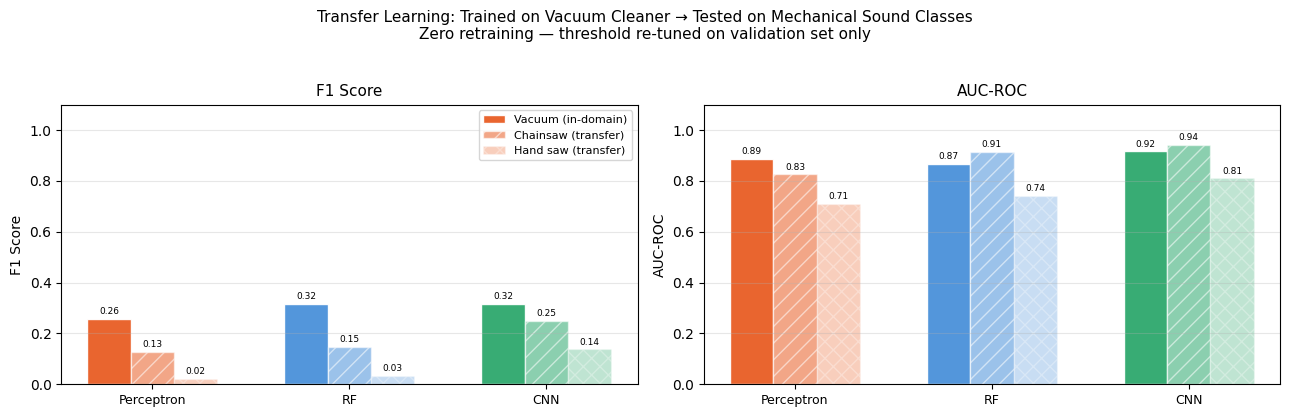

✅  Transfer plot saved.


In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T2 — Transfer vs In-Domain Side-by-Side Plot (Paper Figure 3)
# ─────────────────────────────────────────────────────────────────────────────

# Using the globally defined MODEL_ORDER to avoid conflict with tensorflow.keras.models
model_names_for_plot = MODEL_ORDER
colors  = ["#E85D24", "#4A90D9", "#2DA86D"]
x       = np.arange(len(model_names_for_plot))
width   = 0.22

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, ylabel in zip(axes, ["f1", "auc_roc"], ["F1 Score", "AUC-ROC"]):

    # In-domain (vacuum_cleaner — from your 5-fold results, fold 5)
    indomain_vals = [
        fold_df[(fold_df["model"] == m) &
                (fold_df["fold"]  == 5)][metric].values[0]
        for m in model_names_for_plot
    ]

    # Transfer: chainsaw
    chainsaw_vals = [
        transfer_df[(transfer_df["model"] == m) &
                    (transfer_df["transfer_class"] == "chainsaw")][metric].values[0]
        for m in model_names_for_plot
    ]

    # Transfer: hand_saw
    handsaw_vals = [
        transfer_df[(transfer_df["model"] == m) &
                    (transfer_df["transfer_class"] == "hand_saw")][metric].values[0]
        for m in model_names_for_plot
    ]

    b1 = ax.bar(x - width, indomain_vals,  width, label="Vacuum (in-domain)",
                color=colors, alpha=0.95, edgecolor="white")
    b2 = ax.bar(x,          chainsaw_vals, width, label="Chainsaw (transfer)",
                color=colors, alpha=0.55, edgecolor="white", hatch="//")
    b3 = ax.bar(x + width,  handsaw_vals,  width, label="Hand saw (transfer)",
                color=colors, alpha=0.30, edgecolor="white", hatch="xx")

    ax.set_xticks(x)
    ax.set_xticklabels(["Perceptron", "RF", "CNN"], fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_title(ylabel, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)
    if ax == axes[0]:
        ax.legend(fontsize=8, loc="upper right")

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2,
                    h + 0.01, f"{h:.2f}",
                    ha="center", va="bottom", fontsize=6.5)

plt.suptitle(
    "Transfer Learning: Trained on Vacuum Cleaner → Tested on Mechanical Sound Classes\n"
    "Zero retraining — threshold re-tuned on validation set only",
    fontsize=11, y=1.03,
)
plt.tight_layout()
plt.savefig(CFG.output_dir / "transfer_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Transfer plot saved.")

### Cell 22 — Transfer Learning LaTeX Table

In [51]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 22 — Transfer Learning LaTeX Table  (Table 3 in paper)
# ─────────────────────────────────────────────────────────────────────────────

TRANSFER_CLASSES = ['chainsaw', 'hand_saw']

latex = (
    '\\begin{table}[ht]\n'
    '\\centering\n'
    '\\caption{Transfer learning: models trained on ESC-50 vacuum cleaner, '
    'tested without retraining on acoustically similar classes. '
    'Threshold re-tuned on validation set only.}\n'
    '\\label{tab:transfer}\n'
    '\\begin{tabular}{llcccc}\n'
    '\\hline\n'
    '\\textbf{Model} & \\textbf{Test Class} & \\textbf{F1} '
    '& \\textbf{AUC-ROC} & \\textbf{Recall} & \\textbf{FPR} \\\\\n'
    '\\hline\n'
)

for model in MODEL_ORDER:
    # In-domain row (fold 5)
    id_f1  = fold_df[(fold_df['model']==model) & (fold_df['fold']==5)]['f1'].values[0]
    id_auc = fold_df[(fold_df['model']==model) & (fold_df['fold']==5)]['auc_roc'].values[0]
    latex += f'  {model} & Vacuum (in-domain) & {id_f1:.3f} & {id_auc:.3f} & -- & -- \\\\\n'
    for tc in TRANSFER_CLASSES:
        row = transfer_df[(transfer_df['model']==model) &
                          (transfer_df['transfer_class']==tc)].iloc[0]
        latex += (f'  & {tc.replace("_"," ").title()} & '
                  f'{row.f1:.3f} & {row.auc_roc:.3f} & '
                  f'{row.recall:.3f} & {row.fpr:.3f} \\\\\n')
    latex += '  \\hline\n'

latex += '\\end{tabular}\n\\end{table}\n'
print(latex)
(CFG.output_dir / 'transfer_table.tex').write_text(latex)
print('✅  transfer_table.tex saved.')


\begin{table}[ht]
\centering
\caption{Transfer learning: models trained on ESC-50 vacuum cleaner, tested without retraining on acoustically similar classes. Threshold re-tuned on validation set only.}
\label{tab:transfer}
\begin{tabular}{llcccc}
\hline
\textbf{Model} & \textbf{Test Class} & \textbf{F1} & \textbf{AUC-ROC} & \textbf{Recall} & \textbf{FPR} \\
\hline
  Linear Perceptron & Vacuum (in-domain) & 0.258 & 0.887 & -- & -- \\
  & Chainsaw & 0.127 & 0.827 & 0.500 & 0.130 \\
  & Hand Saw & 0.022 & 0.710 & 0.125 & 0.214 \\
  \hline
  Random Forest & Vacuum (in-domain) & 0.316 & 0.867 & -- & -- \\
  & Chainsaw & 0.148 & 0.914 & 0.250 & 0.043 \\
  & Hand Saw & 0.033 & 0.743 & 0.125 & 0.130 \\
  \hline
  1D-CNN & Vacuum (in-domain) & 0.316 & 0.916 & -- & -- \\
  & Chainsaw & 0.250 & 0.943 & 1.000 & 0.122 \\
  & Hand Saw & 0.139 & 0.811 & 0.875 & 0.219 \\
  \hline
\end{tabular}
\end{table}

✅  transfer_table.tex saved.


---
## Part 7 — Ablation Study
> Tests three MFCC feature configurations across all 5 folds.
> Answers: *"was the Δ + ΔΔ feature engineering choice empirically justified?"*
> ⏱️ Runtime ~90 min on Colab CPU. Set `cnn_epochs=20` for a quick test.

### Cell 23 — MFCC Ablation Driver

In [52]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL A1 — MFCC Feature Ablation Study
# Tests 3 feature configurations × 3 models × 5 folds
# Answers: "was the delta + delta-delta choice justified?"
# ─────────────────────────────────────────────────────────────────────────────

ABLATION_CONFIGS = [
    {"label": "MFCC only",       "n_mfcc": 13, "delta_order": 0},  # 13-dim
    {"label": "MFCC + Δ",        "n_mfcc": 13, "delta_order": 1},  # 26-dim
    {"label": "MFCC + Δ + ΔΔ",  "n_mfcc": 13, "delta_order": 2},  # 39-dim ← current
]

ablation_results = []   # one dict per (config, fold, model)

for cfg_variant in ABLATION_CONFIGS:
    label       = cfg_variant["label"]
    dim         = cfg_variant["n_mfcc"] * (1 + cfg_variant["delta_order"])
    print(f"\n{'='*65}")
    print(f"  CONFIG : {label}  ({dim}-dim feature vector)")
    print(f"{'='*65}")

    # ── Re-extract features for this config ──────────────────────────────────
    def extract_vec_variant(y, n_mfcc, delta_order):
        mfcc = librosa.feature.mfcc(
            y=y, sr=CFG.sample_rate, n_mfcc=n_mfcc,
            n_fft=CFG.n_fft, hop_length=CFG.hop_length,
            n_mels=CFG.n_mels, fmin=CFG.fmin, fmax=CFG.fmax,
        )
        features = [mfcc]
        for order in range(1, delta_order + 1):
            features.append(librosa.feature.delta(mfcc, order=order))
        return np.vstack(features).mean(axis=1).astype(np.float32)

    def extract_seq_variant(y, n_mfcc, delta_order):
        mfcc = librosa.feature.mfcc(
            y=y, sr=CFG.sample_rate, n_mfcc=n_mfcc,
            n_fft=CFG.n_fft, hop_length=CFG.hop_length,
            n_mels=CFG.n_mels, fmin=CFG.fmin, fmax=CFG.fmax,
        )
        features = [mfcc]
        for order in range(1, delta_order + 1):
            features.append(librosa.feature.delta(mfcc, order=order))
        stacked = np.vstack(features).T
        T = stacked.shape[0]
        if T < CFG.max_frames:
            stacked = np.vstack([stacked,
                np.zeros((CFG.max_frames - T, dim), dtype=np.float32)])
        else:
            stacked = stacked[: CFG.max_frames]
        return stacked.astype(np.float32)

    # Build full feature matrices for this variant
    Xv, Xs = [], []
    for _, row in tqdm(meta.iterrows(), total=len(meta),
                       desc=f"Features [{label}]", leave=False):
        wave = waveforms[row["filename"]]
        Xv.append(extract_vec_variant(
            wave, cfg_variant["n_mfcc"], cfg_variant["delta_order"]))
        Xs.append(extract_seq_variant(
            wave, cfg_variant["n_mfcc"], cfg_variant["delta_order"]))

    Xv = np.array(Xv, dtype=np.float32)
    Xs = np.array(Xs, dtype=np.float32)

    # ── 5-fold loop ───────────────────────────────────────────────────────────
    for test_fold in FOLDS:
        val_fold    = (test_fold - 2) % 5 + 1
        train_folds = [f for f in FOLDS if f not in [test_fold, val_fold]]

        train_mask = meta["fold"].isin(train_folds).values
        val_mask   = (meta["fold"] == val_fold).values
        test_mask  = (meta["fold"] == test_fold).values

        X_tr_v, y_tr = Xv[train_mask], y_all[train_mask]
        X_va_v, y_va = Xv[val_mask],   y_all[val_mask]
        X_te_v, y_te = Xv[test_mask],  y_all[test_mask]

        X_tr_s = Xs[train_mask]
        X_va_s = Xs[val_mask]
        X_te_s = Xs[test_mask]

        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(X_tr_v)
        X_va_sc = sc.transform(X_va_v)
        X_te_sc = sc.transform(X_te_v)

        k     = min(5, y_tr.sum() - 1)
        smote = SMOTE(random_state=SEED, sampling_strategy=0.15, k_neighbors=k)
        X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_sc, y_tr)

        cw = {0: 1.0, 1: float((y_tr==0).sum() / max(y_tr.sum(), 1))}

        def best_t(prob_val, y_val):
            best, bf = 0.5, 0.0
            for t in np.arange(0.05, 0.65, 0.01):
                f = f1_score(y_val, (prob_val >= t).astype(int), zero_division=0)
                if f > bf:
                    bf, best = f, t
            return best

        # Perceptron
        perc = CalibratedClassifierCV(
            SGDClassifier(loss="hinge", max_iter=1000, tol=1e-4,
                          random_state=SEED, class_weight="balanced",
                          early_stopping=True, validation_fraction=0.1,
                          n_iter_no_change=20),
            cv=5, method="sigmoid",
        )
        perc.fit(X_tr_sm, y_tr_sm)
        t_p   = best_t(perc.predict_proba(X_va_sc)[:, 1], y_va)
        p_prob = perc.predict_proba(X_te_sc)[:, 1]
        p_pred = (p_prob >= t_p).astype(int)

        # Random Forest
        rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                                    class_weight="balanced",
                                    random_state=SEED, n_jobs=-1)
        rf.fit(X_tr_sm, y_tr_sm)
        t_r   = best_t(rf.predict_proba(X_va_sc)[:, 1], y_va)
        r_prob = rf.predict_proba(X_te_sc)[:, 1]
        r_pred = (r_prob >= t_r).astype(int)

        # CNN
        cnn = build_cnn((CFG.max_frames, dim))
        cnn.fit(
            X_tr_s, y_tr,
            validation_data=(X_va_s, y_va),
            epochs=CFG.cnn_epochs,
            batch_size=CFG.cnn_batch_size,
            class_weight=cw,
            callbacks=[
                callbacks.EarlyStopping(monitor="val_auc", patience=10,
                                        restore_best_weights=True, mode="max"),
                callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                            patience=5, min_lr=1e-6),
            ],
            verbose=0,
        )
        t_c    = best_t(cnn.predict(X_va_s, verbose=0).ravel(), y_va)
        c_prob = cnn.predict(X_te_s, verbose=0).ravel()
        c_pred = (c_prob >= t_c).astype(int)

        for mname, pred, prob in [
            ("Linear Perceptron", p_pred, p_prob),
            ("Random Forest",     r_pred, r_prob),
            ("1D-CNN",            c_pred, c_prob),
        ]:
            ablation_results.append({
                "config"   : label,
                "dim"      : dim,
                "fold"     : test_fold,
                "model"    : mname,
                "f1"       : f1_score(y_te, pred, zero_division=0),
                "auc_roc"  : roc_auc_score(y_te, prob),
                "auc_pr"   : average_precision_score(y_te, prob),
                "fpr"      : confusion_matrix(y_te, pred).ravel()[1] /
                             max(confusion_matrix(y_te, pred).ravel()[1] +
                                 confusion_matrix(y_te, pred).ravel()[0], 1),
            })

print("\n✅  Ablation complete.")


  CONFIG : MFCC only  (13-dim feature vector)


Features [MFCC only]:   0%|          | 0/2000 [00:00<?, ?it/s]


  CONFIG : MFCC + Δ  (26-dim feature vector)


Features [MFCC + Δ]:   0%|          | 0/2000 [00:00<?, ?it/s]


  CONFIG : MFCC + Δ + ΔΔ  (39-dim feature vector)


Features [MFCC + Δ + ΔΔ]:   0%|          | 0/2000 [00:00<?, ?it/s]


✅  Ablation complete.


### Cell 24 — Aggregate Ablation Results

In [53]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL A2 — Aggregate Ablation Results
# ─────────────────────────────────────────────────────────────────────────────

abl_df = pd.DataFrame(ablation_results)

abl_agg = (
    abl_df.groupby(["config", "model"])
    .agg(
        f1_mean   =("f1",      "mean"),
        f1_std    =("f1",      "std"),
        auc_mean  =("auc_roc", "mean"),
        auc_std   =("auc_roc", "std"),
        fpr_mean  =("fpr",     "mean"),
        fpr_std   =("fpr",     "std"),
    )
    .round(4)
    .reset_index()
)

print("\n" + "═"*75)
print("  ABLATION STUDY — MFCC Feature Configuration")
print("  Metric: mean ± std across 5 folds")
print("═"*75)

config_order = ["MFCC only", "MFCC + Δ", "MFCC + Δ + ΔΔ"]
model_order  = ["Linear Perceptron", "Random Forest", "1D-CNN"]

for model in model_order:
    print(f"\n  {model}")
    print(f"  {'Config':<18} {'Dim':>5}  {'F1':>12}  {'AUC-ROC':>12}  {'FPR':>12}")
    print(f"  {'-'*65}")
    for cfg_label in config_order:
        row = abl_agg[(abl_agg["config"] == cfg_label) &
                      (abl_agg["model"]  == model)].iloc[0]
        dim = {"MFCC only": 13, "MFCC + Δ": 26, "MFCC + Δ + ΔΔ": 39}[cfg_label]
        marker = " ←" if cfg_label == "MFCC + Δ + ΔΔ" else ""
        print(f"  {cfg_label:<18} {dim:>5}  "
              f"{row.f1_mean:.3f}±{row.f1_std:.3f}  "
              f"{row.auc_mean:.3f}±{row.auc_std:.3f}  "
              f"{row.fpr_mean:.3f}±{row.fpr_std:.3f}{marker}")

print("═"*75)
abl_df.to_csv(CFG.output_dir / "ablation_results.csv", index=False)
abl_agg.to_csv(CFG.output_dir / "ablation_summary.csv", index=False)
print("✅  Ablation results saved.")


═══════════════════════════════════════════════════════════════════════════
  ABLATION STUDY — MFCC Feature Configuration
  Metric: mean ± std across 5 folds
═══════════════════════════════════════════════════════════════════════════

  Linear Perceptron
  Config               Dim            F1       AUC-ROC           FPR
  -----------------------------------------------------------------
  MFCC only             13  0.224±0.098  0.879±0.060  0.019±0.004
  MFCC + Δ              26  0.254±0.104  0.906±0.053  0.025±0.011
  MFCC + Δ + ΔΔ         39  0.221±0.060  0.898±0.043  0.045±0.017 ←

  Random Forest
  Config               Dim            F1       AUC-ROC           FPR
  -----------------------------------------------------------------
  MFCC only             13  0.264±0.151  0.906±0.046  0.029±0.018
  MFCC + Δ              26  0.320±0.163  0.913±0.067  0.026±0.018
  MFCC + Δ + ΔΔ         39  0.433±0.208  0.900±0.058  0.015±0.004 ←

  1D-CNN
  Config               Dim            F1   

### Cell 25 — Ablation Plot

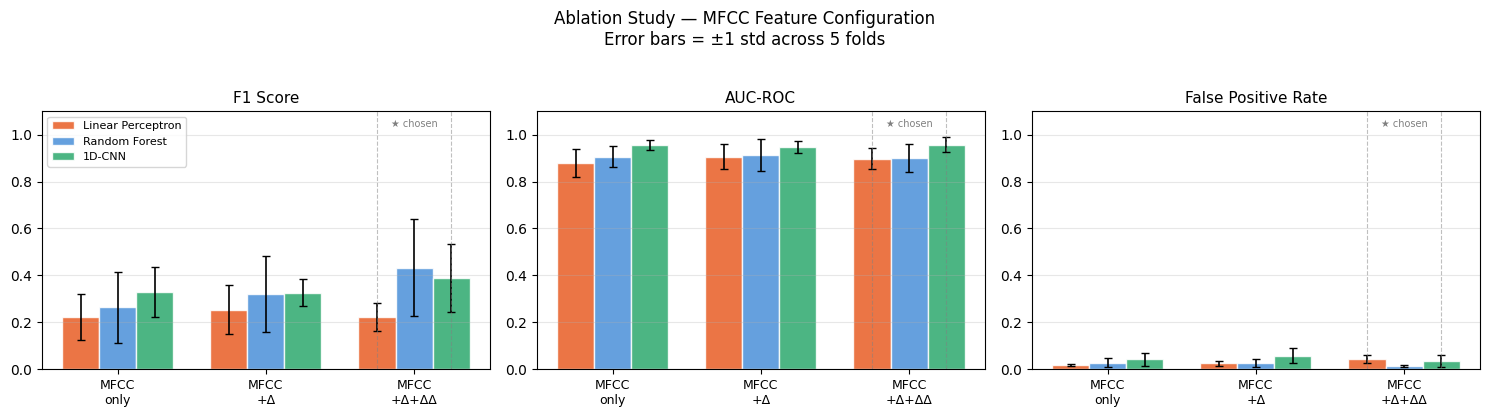

✅  Ablation plot saved.


In [54]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL A3 — Ablation Plot
# Grouped bars: x-axis = feature config, groups = models, metric = F1 + AUC
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics  = ["f1_mean",  "auc_mean",  "fpr_mean"]
stds     = ["f1_std",   "auc_std",   "fpr_std"]
titles   = ["F1 Score", "AUC-ROC",   "False Positive Rate"]
colors   = ["#E85D24",  "#4A90D9",   "#2DA86D"]

x      = np.arange(len(config_order))
width  = 0.25

for ax, metric, std_col, title in zip(axes, metrics, stds, titles):
    for i, (model, color) in enumerate(zip(model_order, colors)):
        vals = [
            abl_agg[(abl_agg["config"] == c) &
                    (abl_agg["model"]  == model)][metric].values[0]
            for c in config_order
        ]
        errs = [
            abl_agg[(abl_agg["config"] == c) &
                    (abl_agg["model"]  == model)][std_col].values[0]
            for c in config_order
        ]
        offset = (i - 1) * width
        bars = ax.bar(x + offset, vals, width, label=model,
                      color=color, alpha=0.85, edgecolor="white")
        ax.errorbar(x + offset, vals, yerr=errs,
                    fmt="none", color="black", capsize=3, linewidth=1.2)

    ax.set_xticks(x)
    ax.set_xticklabels(["MFCC\nonly", "MFCC\n+Δ", "MFCC\n+Δ+ΔΔ"], fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.grid(axis="y", alpha=0.3)
    if ax == axes[0]:
        ax.legend(fontsize=8)

    # Highlight best config with a bracket
    ax.axvline(x=2 - width, color="gray", ls="--", lw=0.8, alpha=0.5)
    ax.axvline(x=2 + width, color="gray", ls="--", lw=0.8, alpha=0.5)
    ax.text(2, ax.get_ylim()[1] * 0.97, "★ chosen",
            ha="center", va="top", fontsize=7, color="gray")

plt.suptitle(
    "Ablation Study — MFCC Feature Configuration\n"
    "Error bars = ±1 std across 5 folds",
    fontsize=12, y=1.03,
)
plt.tight_layout()
plt.savefig(CFG.output_dir / "ablation_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Ablation plot saved.")

### Cell 26 — Ablation LaTeX Table

In [55]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 26 — Ablation LaTeX Table  (Table 2 in paper)
# ─────────────────────────────────────────────────────────────────────────────

config_order = ['MFCC only', 'MFCC + Δ', 'MFCC + Δ + ΔΔ']
dim_map      = {'MFCC only': 13, 'MFCC + Δ': 26, 'MFCC + Δ + ΔΔ': 39}

latex = (
    '\\begin{table}[ht]\n'
    '\\centering\n'
    '\\caption{Ablation: effect of MFCC feature configuration on 5-fold '
    'cross-validation performance. Chosen configuration marked $\\star$.}\n'
    '\\label{tab:ablation}\n'
    '\\begin{tabular}{llccc}\n'
    '\\hline\n'
    '\\textbf{Model} & \\textbf{Features} & \\textbf{Dim} '
    '& \\textbf{F1} & \\textbf{AUC-ROC} \\\\\n'
    '\\hline\n'
)

model_order = ['Linear Perceptron', 'Random Forest', '1D-CNN']
for model in model_order:
    first = True
    for cfg_label in config_order:
        row   = abl_agg[(abl_agg['config']==cfg_label) & (abl_agg['model']==model)].iloc[0]
        dim   = dim_map[cfg_label]
        star  = ' $\\star$' if cfg_label == 'MFCC + Δ + ΔΔ' else ''
        mname = model if first else ''
        first = False
        latex += (f'  {mname} & {cfg_label}{star} & {dim} & '
                  f'${row.f1_mean:.3f}\\pm{row.f1_std:.3f}$ & '
                  f'${row.auc_mean:.3f}\\pm{row.auc_std:.3f}$ \\\\\n')
    latex += '  \\hline\n'

latex += '\\end{tabular}\n\\end{table}\n'
print(latex)
(CFG.output_dir / 'ablation_table.tex').write_text(latex)
print('✅  ablation_table.tex saved.')


\begin{table}[ht]
\centering
\caption{Ablation: effect of MFCC feature configuration on 5-fold cross-validation performance. Chosen configuration marked $\star$.}
\label{tab:ablation}
\begin{tabular}{llccc}
\hline
\textbf{Model} & \textbf{Features} & \textbf{Dim} & \textbf{F1} & \textbf{AUC-ROC} \\
\hline
  Linear Perceptron & MFCC only & 13 & $0.224\pm0.098$ & $0.879\pm0.060$ \\
   & MFCC + Δ & 26 & $0.254\pm0.104$ & $0.906\pm0.053$ \\
   & MFCC + Δ + ΔΔ $\star$ & 39 & $0.221\pm0.060$ & $0.898\pm0.043$ \\
  \hline
  Random Forest & MFCC only & 13 & $0.264\pm0.151$ & $0.906\pm0.046$ \\
   & MFCC + Δ & 26 & $0.320\pm0.163$ & $0.913\pm0.067$ \\
   & MFCC + Δ + ΔΔ $\star$ & 39 & $0.433\pm0.208$ & $0.900\pm0.058$ \\
  \hline
  1D-CNN & MFCC only & 13 & $0.329\pm0.105$ & $0.957\pm0.022$ \\
   & MFCC + Δ & 26 & $0.326\pm0.058$ & $0.948\pm0.026$ \\
   & MFCC + Δ + ΔΔ $\star$ & 39 & $0.389\pm0.145$ & $0.958\pm0.032$ \\
  \hline
\end{tabular}
\end{table}

✅  ablation_table.tex saved.


---
## Part 8 — Final Summary
### Cell 27 — Summary Dashboard & File Manifest

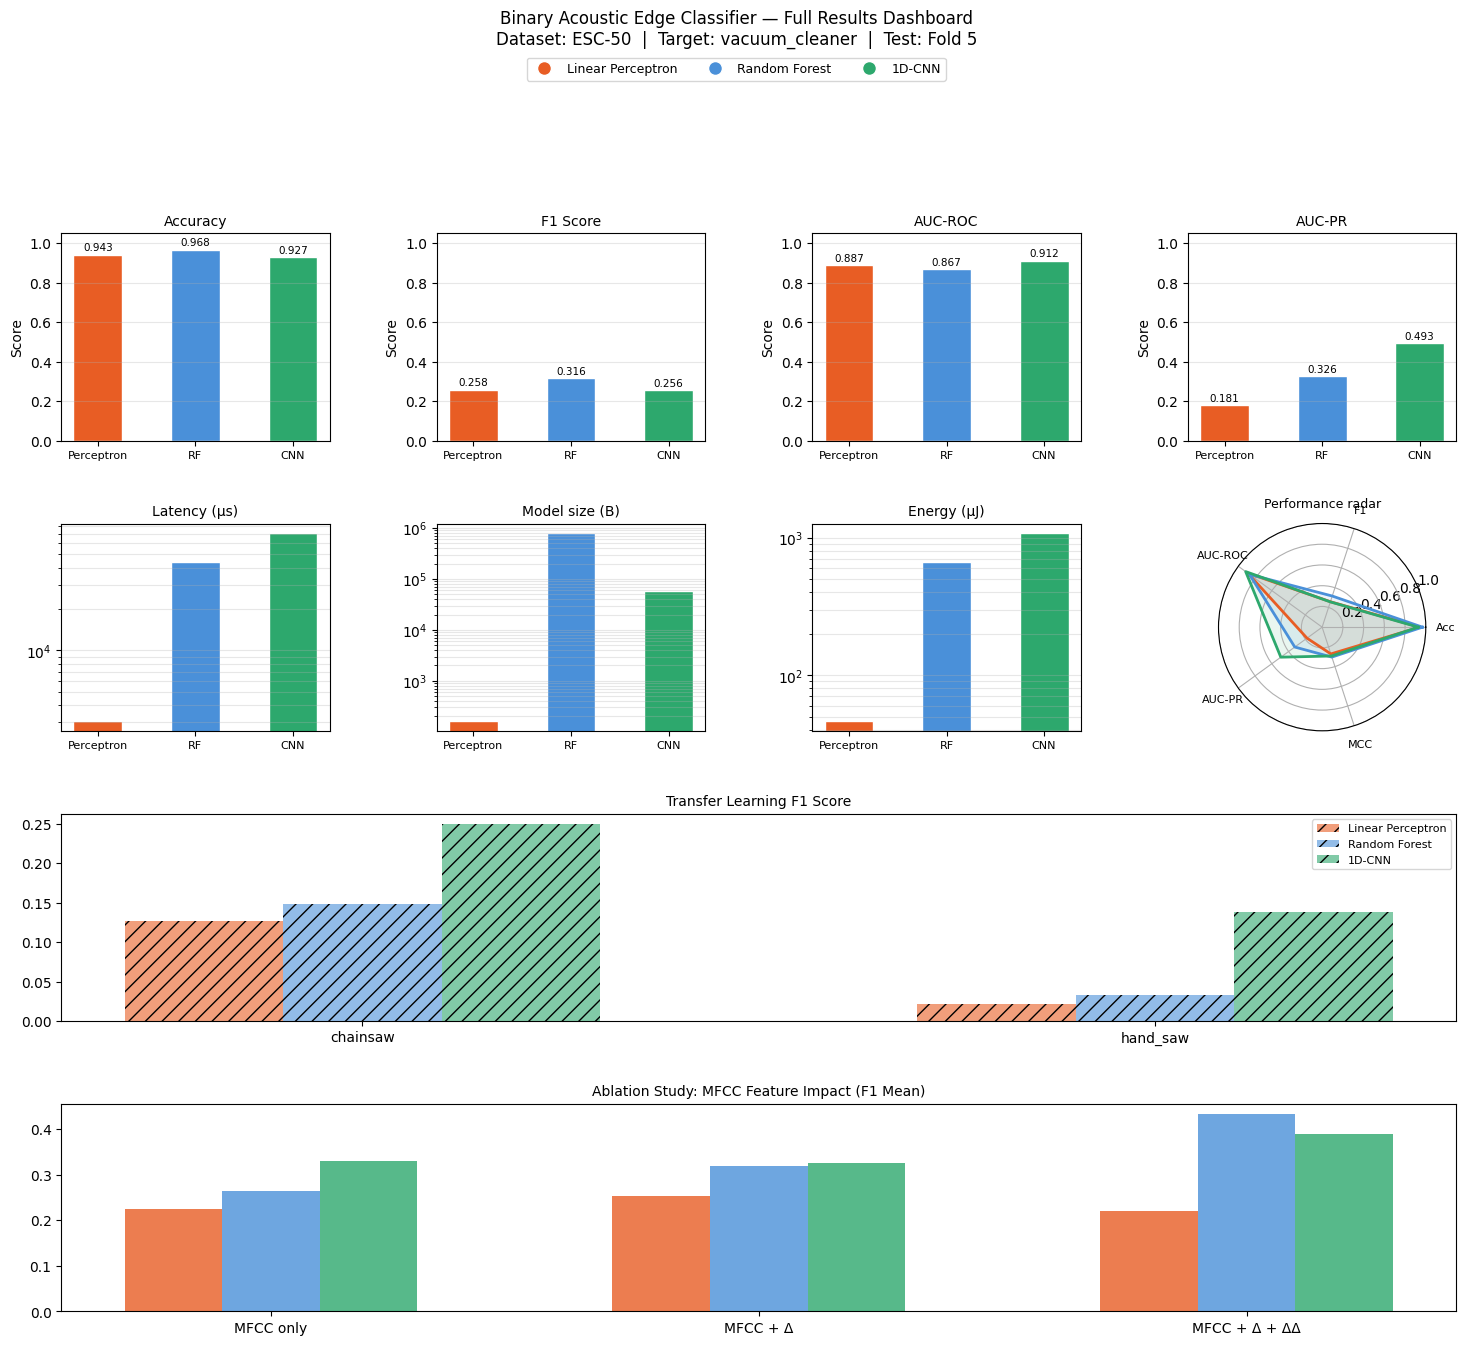


════════════════════════════════════════════════════════════
  OUTPUT FILES
════════════════════════════════════════════════════════════
  ablation_plot.png                           60.8 KB
  ablation_results.csv                         4.6 KB
  ablation_summary.csv                         0.6 KB
  ablation_table.tex                           0.9 KB
  confusion_matrices.png                      92.4 KB
  cv5_f1_per_fold.png                         70.1 KB
  cv5_per_fold.csv                             2.3 KB
  cv5_results.png                             60.4 KB
  cv5_summary.csv                              0.4 KB
  cv5_table.tex                                0.6 KB
  fpr_by_category.csv                          1.2 KB
  fpr_by_category.png                        227.2 KB
  mfcc_samples.png                           152.5 KB
  pareto_accuracy_energy.png                  83.1 KB
  resource_comparison.png                     59.3 KB
  roc_pr_curves.png                          115.6 K

In [56]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 18 — Final Summary Dashboard + File Manifest
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(4, 4, figure=fig, hspace=0.4, wspace=0.4)

metrics_top = [("accuracy","Accuracy"),("f1","F1 Score"),
               ("auc_roc","AUC-ROC"),("auc_pr","AUC-PR")]
model_names  = [r["model"] for r in results]
colors_list  = [COLORS[n]  for n in model_names]

for col, (metric, label) in enumerate(metrics_top):
    ax   = fig.add_subplot(gs[0, col])
    vals = [r[metric] for r in results]
    bars = ax.bar(range(len(results)), vals, color=colors_list,
                  width=0.5, edgecolor="white")
    ax.set_xticks(range(len(results)))
    ax.set_xticklabels(["Perceptron","RF","CNN"], fontsize=8)
    ax.set_ylim(0, 1.05); ax.set_title(label, fontsize=10)
    ax.set_ylabel("Score"); ax.grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)

for col, (metric, label) in enumerate([("infer_us","Latency (µs)"),
                                        ("size_bytes","Model size (B)"),
                                        ("energy_uj","Energy (µJ)")]):
    ax   = fig.add_subplot(gs[1, col])
    vals = [r[metric] for r in results]
    ax.bar(range(len(results)), vals, color=colors_list, width=0.5, edgecolor="white")
    ax.set_xticks(range(len(results)))
    ax.set_xticklabels(["Perceptron","RF","CNN"], fontsize=8)
    ax.set_yscale("log"); ax.set_title(label, fontsize=10)
    ax.grid(axis="y", alpha=0.3, which="both")

ax_r = fig.add_subplot(gs[1, 3], polar=True)
radar_metrics = ["accuracy","f1","auc_roc","auc_pr","mcc"]
radar_labels  = ["Acc","F1","AUC-ROC","AUC-PR","MCC"]
N      = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
for res in results:
    vals = [max(res[m], 0) for m in radar_metrics] + [max(res[radar_metrics[0]], 0)]
    ax_r.plot(angles, vals, color=COLORS[res["model"]], lw=2)
    ax_r.fill(angles, vals, color=COLORS[res["model"]], alpha=0.1)
ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(radar_labels, fontsize=8)
ax_r.set_ylim(0, 1); ax_r.set_title("Performance radar", fontsize=9, pad=12)

# --- Transfer Section ---
if 'transfer_df' in locals():
    ax_tr = fig.add_subplot(gs[2, :])
    classes = transfer_df['transfer_class'].unique()
    x_idx = np.arange(len(classes))
    w = 0.2
    for i, m in enumerate(["Linear Perceptron", "Random Forest", "1D-CNN"]):
        vals = [transfer_df[(transfer_df['transfer_class']==c) & (transfer_df['model']==m)]['f1'].values[0] for c in classes]
        ax_tr.bar(x_idx + (i-1)*w, vals, w, label=m, color=COLORS[m], alpha=0.6, hatch='//')
    ax_tr.set_xticks(x_idx); ax_tr.set_xticklabels(classes)
    ax_tr.set_title("Transfer Learning F1 Score", fontsize=10)
    ax_tr.legend(fontsize=8, loc='upper right')

# --- Ablation Section ---
if 'abl_agg' in locals():
    ax_abl = fig.add_subplot(gs[3, :])
    config_labels = ["MFCC only", "MFCC + Δ", "MFCC + Δ + ΔΔ"]
    x_idx = np.arange(len(config_labels))
    w = 0.2
    for i, model in enumerate(["Linear Perceptron", "Random Forest", "1D-CNN"]):
        means = [abl_agg[(abl_agg['config'] == c) & (abl_agg['model'] == model)]['f1_mean'].values[0] for c in config_labels]
        ax_abl.bar(x_idx + (i-1)*w, means, w, label=model, color=COLORS[model], alpha=0.8)
    ax_abl.set_xticks(x_idx); ax_abl.set_xticklabels(config_labels)
    ax_abl.set_title("Ablation Study: MFCC Feature Impact (F1 Mean)", fontsize=10)

legend_handles = [plt.Line2D([0],[0],marker="o",color="w",
                  markerfacecolor=COLORS[r["model"]],markersize=10,label=r["model"])
                  for r in results]
fig.legend(handles=legend_handles, loc="upper center", ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, 1.01))
fig.suptitle(f"Binary Acoustic Edge Classifier — Full Results Dashboard\n"
             f"Dataset: ESC-50  |  Target: {CFG.target_class}  |  Test: Fold 5",
             fontsize=12, y=1.04)
plt.savefig(CFG.output_dir / "summary_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "═"*60)
print("  OUTPUT FILES")
print("═"*60)
for f in sorted(CFG.output_dir.glob("*")):
    print(f"  {f.name:<40}  {f.stat().st_size/1024:>6.1f} KB")
for f in sorted(CFG.model_dir.glob("*")):
    print(f"  models/{f.name:<33}  {f.stat().st_size/1024:>6.1f} KB")
print("═"*60)
print("\n✨  Pipeline complete. All outputs saved to ./results/ and ./models/")
print(f"\nConfig:\n{json.dumps(asdict(CFG), indent=2, default=str)}")